In [1]:
!pip install metrics ruptures ordpy colorednoise catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00


In [2]:
%%writefile data_generation2.py
import numpy as np
import pandas as pd
import colorednoise as cn

class Binary_Telegraph_Process:
    def __init__(self, length, generator=None, p1=0, p2=1, RANDOM_SEED=None, alpha=1):
        if RANDOM_SEED is not None: np.random.seed(RANDOM_SEED)
        self.length = length


        self.change_points = np.sort(np.random.choice(range(100, length-100), 10, replace=False))
        self.spikes = np.random.choice(range(100, length-100), 5, replace=False)

        self.labels_ = np.zeros(length)
        self.labels_[self.change_points] = 1
        self.labels_[self.spikes] = 2

        self.data = np.zeros(length)
        indices = np.append(np.insert(self.change_points, 0, 0), length)

        for i in range(len(indices)-1):
            start, end = indices[i], indices[i+1]
            regime = i % 2

            if generator == np.random.normal:
                self.data[start:end] = generator(p1 + (regime * alpha), p2, end-start)
            else:
                self.data[start:end] = generator(alpha, end-start) + (regime * alpha)

        self.data[self.spikes] += (np.random.choice([-1, 1], len(self.spikes)) * alpha * 5)

    def get_data(self): return self.data
    def labels(self): return pd.DataFrame({'levels': self.labels_})

Writing data_generation2.py


In [3]:
import sys
import numpy as np
import pandas as pd
import colorednoise as cn
import data_generation2

class RobustBTP:
    def __init__(self, length, generator=None, p1=0, p2=1, RANDOM_SEED=None, alpha=1):
        if RANDOM_SEED is not None: np.random.seed(RANDOM_SEED)
        self.length = length

        self.change_points = np.sort(np.random.choice(range(100, length-100), 10, replace=False))
        self.spikes = np.random.choice(range(100, length-100), 5, replace=False)
        self.labels_ = np.zeros(length)
        self.labels_[self.change_points] = 1
        self.labels_[self.spikes] = 2

        self.data = np.zeros(length)
        indices = np.append(np.insert(self.change_points, 0, 0), length)

        for i in range(len(indices)-1):
            start, end = indices[i], indices[i+1]
            regime = i % 2
            samples = end - start

            if p1 == 'el_nino':
                self.data[start:end] = np.random.normal(regime, 0.5, samples) + np.sin(np.arange(start, end)/20)
            elif generator == np.random.normal:
                self.data[start:end] = generator(regime, p2, samples)
            elif generator is not None:
                self.data[start:end] = generator(alpha, samples) + (regime * 2)
            else:
                self.data[start:end] = np.random.normal(regime, 1, samples)

        self.data[self.spikes] += (np.random.choice([-1, 1], len(self.spikes)) * 5)

    def get_data(self): return self.data
    def labels(self): return pd.DataFrame({'levels': self.labels_})

data_generation2.Binary_Telegraph_Process = RobustBTP

In [4]:
import re
import math
import torch
# import metrics
import ruptures
import ordpy as op
import numpy as np
import pandas as pd
import ruptures as rpt
# from klcpd import KL_CPD
import scipy.stats as st
import colorednoise as cn
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import matplotlib.ticker as tck
# from xgboost import XGBClassifier
from collections import OrderedDict
# from LSTM.models import binary_model
from catboost import CatBoostClassifier
from IPython.display import clear_output
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from ruptures.metrics import randindex, precision_recall
from data_generation2 import Binary_Telegraph_Process as BTP
from sklearn.model_selection import train_test_split as tts
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import balanced_accuracy_score, f1_score, auc, precision_recall_curve

import warnings
warnings.filterwarnings('ignore')

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# os.environ['KMP_DUPLICATE_LIB_OK']='True'
# from xgboost import XGBClassifier

In [5]:
class synth_cpd_pipeline(object):
    def __init__(self, method='log-return', sample_len=10000, n_epochs=100, save_results=False):

        self.data   = {r'Белый, $\alpha = 1$':[], r'Белый, $\alpha = 2$':[], r'Белый, $\alpha = \pi$':[],
                       r'Розовый, $\alpha = 1$':[], r'Розовый, $\alpha = 2$':[], r'Розовый, $\alpha = \pi$':[],
                       r'Красный, $\alpha = 1$':[], r'Красный, $\alpha = 2$':[], r'Красный, $\alpha = \pi$':[],
                       r'Синий, $\alpha = 1$':[], r'Синий, $\alpha = 2$':[], r'Синий, $\alpha = \pi$':[],
                       r'Фиолетовый, $\alpha = 1$':[], r'Фиолетовый, $\alpha = 2$':[], r'Фиолетовый, $\alpha = \pi$':[],
                       r'el_nino, $\alpha = 1$':[], r'el_nino, $\alpha = 2$':[], r'el_nino, $\alpha = \pi$':[]}
        self.labels = []
        self.lr     = []
        self.noise  = [r'Белый, $\alpha = 1$', r'Розовый, $\alpha = 1$', r'Красный, $\alpha = 1$', r'Синий, $\alpha = 1$', r'Фиолетовый, $\alpha = 1$', r'el_nino, $\alpha = 1$',
                       r'Белый, $\alpha = 2$', r'Розовый, $\alpha = 2$', r'Красный, $\alpha = 2$', r'Синий, $\alpha = 2$', r'Фиолетовый, $\alpha = 2$', r'el_nino, $\alpha = 2$',
                       r'Белый, $\alpha = \pi$', r'Розовый, $\alpha = \pi$', r'Красный, $\alpha = \pi$', r'Синий, $\alpha = \pi$', r'Фиолетовый, $\alpha = \pi$', r'el_nino, $\alpha = \pi$']
        self.method = method
        self.sample_len = sample_len
        self.random_seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] # el_nino
        self.horizon = [1, 2, 5, 10, 25]#, 10, 100]
        self.n_epochs = n_epochs
        self.save_results = save_results


    def init_data(self):

        for seed in self.random_seeds:
            # Normal
            self.data[r'Белый, $\alpha = 1$'].append(BTP(self.sample_len, np.random.normal, 0, 1, RANDOM_SEED=seed))
            self.data[r'Белый, $\alpha = 2$'].append(BTP(self.sample_len, np.random.normal, 0, 2, RANDOM_SEED=seed))
            self.data[r'Белый, $\alpha = \pi$'].append(BTP(self.sample_len, np.random.normal, 0, math.pi, RANDOM_SEED=seed))
            # Pink
            self.data[r'Розовый, $\alpha = 1$'].append(BTP(self.sample_len, cn.powerlaw_psd_gaussian, 1, RANDOM_SEED=seed, alpha=1))
            self.data[r'Розовый, $\alpha = 2$'].append(BTP(self.sample_len, cn.powerlaw_psd_gaussian, 1, RANDOM_SEED=seed, alpha=2))
            self.data[r'Розовый, $\alpha = \pi$'].append(BTP(self.sample_len, cn.powerlaw_psd_gaussian, 1, RANDOM_SEED=seed, alpha=math.pi))
            # Red
            self.data[r'Красный, $\alpha = 1$'].append(BTP(self.sample_len, cn.powerlaw_psd_gaussian, 2, RANDOM_SEED=seed, alpha=1))
            self.data[r'Красный, $\alpha = 2$'].append(BTP(self.sample_len, cn.powerlaw_psd_gaussian, 2, RANDOM_SEED=seed, alpha=2))
            self.data[r'Красный, $\alpha = \pi$'].append(BTP(self.sample_len, cn.powerlaw_psd_gaussian, 2, RANDOM_SEED=seed, alpha=math.pi))
            # Blue
            self.data[r'Синий, $\alpha = 1$'].append(BTP(self.sample_len, cn.powerlaw_psd_gaussian, -1, RANDOM_SEED=seed, alpha=1))
            self.data[r'Синий, $\alpha = 2$'].append(BTP(self.sample_len, cn.powerlaw_psd_gaussian, -1, RANDOM_SEED=seed, alpha=2))
            self.data[r'Синий, $\alpha = \pi$'].append(BTP(self.sample_len, cn.powerlaw_psd_gaussian, -1, RANDOM_SEED=seed, alpha=math.pi))
            # Violet
            self.data[r'Фиолетовый, $\alpha = 1$'].append(BTP(self.sample_len, cn.powerlaw_psd_gaussian, -2, RANDOM_SEED=seed, alpha=1))
            self.data[r'Фиолетовый, $\alpha = 2$'].append(BTP(self.sample_len, cn.powerlaw_psd_gaussian, -2, RANDOM_SEED=seed, alpha=2))
            self.data[r'Фиолетовый, $\alpha = \pi$'].append(BTP(self.sample_len, cn.powerlaw_psd_gaussian, -2, RANDOM_SEED=seed, alpha=math.pi))
            # el_nino
            self.data[r'el_nino, $\alpha = 1$'].append(BTP(self.sample_len, p1 = 'el_nino', RANDOM_SEED=seed))
            self.data[r'el_nino, $\alpha = 2$'].append(BTP(self.sample_len, p1 = 'el_nino', RANDOM_SEED=seed))
            self.data[r'el_nino, $\alpha = \pi$'].append(BTP(self.sample_len, p1 = 'el_nino', RANDOM_SEED=seed))

    def autoregression_matrix(self, X, periods=1, fill_value=0):
        shifted_x = [pd.DataFrame(X).shift(periods=i, fill_value=fill_value).values for i in range(periods)]
        return np.hstack(tuple(shifted_x))

    def single_cpd_predict(self, noise):

        qms = []
        f1, acc, pr = dict.fromkeys(self.horizon), dict.fromkeys(self.horizon), dict.fromkeys(self.horizon)

        for btp in tqdm(self.data[noise], desc=noise):

            X = np.array(btp.get_data())
            L = btp.labels()#['levels'].values
            y = np.array(btp.labels_)
            # y[y > 0] = 1

            if self.method == 'lstm':
                lstm = binary_model(X.astype(np.float32), 0.7, 10, model='lstm', n_epochs=self.n_epochs)
                lstm.model_fit(verbose=0)

            single_qms = []

            for h in self.horizon:

                X_auto = self.autoregression_matrix(X, periods=h)

                mask = np.isfinite(X_auto).all(axis=1) & np.isfinite(y)
                X_auto = X_auto[mask]
                y = y[mask]

                X_train, X_test, y_train, y_test = tts(X_auto, y, test_size=0.5, shuffle=True, stratify=y)

                if self.method == 'LDA':

                    mdl = LinearDiscriminantAnalysis()
                    mdl.fit(X_train, y_train)
                    y_pred = mdl.predict(X_test)
                    y_true = y_test

                if self.method == 'QDA':

                    mdl = QuadraticDiscriminantAnalysis()
                    mdl.fit(X_train, y_train)
                    y_pred = mdl.predict(X_test)
                    y_true = y_test

                elif self.method == 'MLP':

                    mdl = MLPClassifier()
                    mdl.fit(X_train, y_train)
                    y_pred = mdl.predict(X_test)
                    y_true = y_test
                elif self.method == 'n-beats':
                    X_input = torch.tensor(X_auto[:, 1:], dtype=torch.float32)
                    y_target = torch.tensor(X_auto[:, 0], dtype=torch.float32).view(-1, 1)

                    model = SimpleNBeats(X_input.shape[1])
                    optimizer = optim.Adam(model.parameters(), lr=0.01)
                    criterion = nn.MSELoss()

                    for _ in range(20):
                        optimizer.zero_grad(); loss = criterion(model(X_input), y_target)
                        loss.backward(); optimizer.step()

                    with torch.no_grad():
                        errors = np.abs(X_auto[:, 0].reshape(-1, 1) - model(X_input).numpy()).flatten()

                        y_pred = np.zeros_like(errors)
                        y_pred[errors > np.percentile(errors, 92)] = 1
                        y_pred[errors > np.percentile(errors, 98)] = 2

                        y_true = y.astype(int)

                if self.method == 'Binseg':

                    y1 = y[mask]
                    signal = X_auto
                    if signal.ndim == 1:
                        signal = signal.reshape(-1, 1)

                    algo = rpt.Binseg(model='l2').fit(signal)
                    predicted_bkps = algo.predict(pen=3)

                    y_pred = np.zeros_like(y1)
                    y_pred[predicted_bkps[:-1]] = 1

                    y_true = np.zeros_like(y1)
                    y_true[np.where(np.diff(y1) != 0)[0]] = 1

                if self.method == 'Window':

                    y1 = y[mask]
                    signal = X_auto
                    if signal.ndim == 1:
                        signal = signal.reshape(-1, 1)

                    algo = rpt.Window(model='l2').fit(signal)
                    predicted_bkps = algo.predict(pen=3)

                    y_pred = np.zeros_like(y1)
                    y_pred[predicted_bkps[:-1]] = 1

                    y_true = np.zeros_like(y1)
                    y_true[np.where(np.diff(y1) != 0)[0]] = 1

                elif self.method == 'Pelt':

                    y1 = y[mask]
                    signal = X_auto
                    if signal.ndim == 1:
                        signal = signal.reshape(-1, 1)

                    model = "l1"  # "l2", "rbf"
                    algo = rpt.Pelt(model=model, min_size=3, jump=5).fit(signal)
                    my_bkps = algo.predict(pen=3)

                    y_pred = np.zeros_like(y1)
                    y_pred[my_bkps[:-1]] = 1

                    y_true = np.zeros_like(y1)
                    y_true[np.where(np.diff(y1) != 0)[0]] = 1


                f1_ = f1_score(y_true, y_pred, average='weighted', labels=np.unique(y_pred))
                acc_ = balanced_accuracy_score(y_true, y_pred)
                # precision, recall, thr = precision_recall_curve(y_true, y_pred)
                # pr_ = auc(recall, precision)
                y_true_bin = (y_true > 0).astype(int)

                y_pred_bin = (y_pred > 0).astype(int)

                precision, recall, _ = precision_recall_curve(y_true_bin, y_pred_bin)

                pr_ = auc(recall, precision)

                single_qms.append([f1_, acc_, pr_])

            qms.append(single_qms)

        mu = np.mean(qms, axis=0)
        er = np.std(qms, axis=0) / np.sqrt(len(qms))

        print(mu)

        for h_i, h in enumerate(self.horizon):
            f1[h] = "%.3f ± %.3f" % (mu[h_i][0], er[h_i][0])
            acc[h] = "%.3f ± %.3f" % (mu[h_i][1], er[h_i][1])
            pr[h] = "%.3f ± %.3f" % (mu[h_i][2], er[h_i][2])

        return f1, acc, pr

    def cpd_predict(self):
        f1, acc, pr = dict.fromkeys(self.noise), dict.fromkeys(self.noise), dict.fromkeys(self.noise)

        if len(self.lr) == 0:
            self.init_data()

        for noise in tqdm(self.data.keys(), leave=True, position=0):
            if (self.method == 'LDA') and (noise == r'Синий, $\alpha = 1$' or noise == r'Фиолетовый, $\alpha = 1$'):
                continue
            if (self.method == 'QDA') and (noise == r'Синий, $\alpha = 1$' or noise == r'Фиолетовый, $\alpha = 1$'):
                continue
            if (self.method == 'MLP') and (noise == r'Синий, $\alpha = 1$' or noise == r'Фиолетовый, $\alpha = 1$'):
                continue
            if (self.method == 'Binseg') and (noise == r'Синий, $\alpha = 1$' or noise == r'Фиолетовый, $\alpha = 1$'):
                continue
            if (self.method == 'Pelt') and (noise == r'Синий, $\alpha = 1$' or noise == r'Фиолетовый, $\alpha = 1$'):
                continue
            if (self.method == 'Window') and (noise == r'Синий, $\alpha = 1$' or noise == r'Фиолетовый, $\alpha = 1$'):
                continue
            f1[noise], acc[noise], pr[noise] = self.single_cpd_predict(noise)

        f1, acc, pr = pd.DataFrame(f1).T, pd.DataFrame(acc).T, pd.DataFrame(pr).T

        if self.save_results:
            f1.sort_index(inplace=True)
            acc.sort_index(inplace=True)
            pr.sort_index(inplace=True)

            f1.to_csv(f'{self.method}_f1.csv')
            acc.to_csv(f'{self.method}_acc.csv')
            pr.to_csv(f'{self.method}_pr.csv')

        self.f1 = f1
        self.acc = acc
        self.pr = pr

    def plot_delta_t(self, n_bins=20):

        self.init_data()

        fig, ax = plt.subplots(ncols=6, nrows=3, figsize=(20, 10))

        c = 0

        for i, noise in enumerate(self.noise):

            labels = np.array([])
            for btp in self.data[noise]:
                X = np.array(btp.get_data())
                L = btp.labels()
                y = np.array(btp.labels_)
                label = np.arange(len(y))[y > 0]
                labels = np.concatenate((labels, np.abs(label[1:]-label[:-1])))

            labels = np.array(labels).squeeze()

            # print(noise, )
            c += len(labels)/10_000

            ax[i//6, i%6].set_yscale('log')
            ax[i//6, i%6].hist(labels, n_bins)
            if i%6 == 0:
                ax[i//6, i%6].set_ylabel('Частота', fontsize=16, weight='bold')
            if i//6 == 2:
                ax[i//6, i%6].set_xlabel(r'$\Delta$ t', fontsize=16, weight='bold')
            ax[i//6, i%6].set_title(noise, fontsize=16)
            ax[i//6, i%6].tick_params(labelsize=16)

        # print(c / 15)

        fig.suptitle('Частоты расстоянии между точками разладки', fontsize=20, weight='bold')
        plt.tight_layout()
        plt.show()

        # fig.savefig('histogram_changes.jpeg', format='jpeg', dpi=200)

In [6]:
def CPD(method):

    cpd = synth_cpd_pipeline(method = method, save_results=True)
    cpd.plot_delta_t()

    return cpd

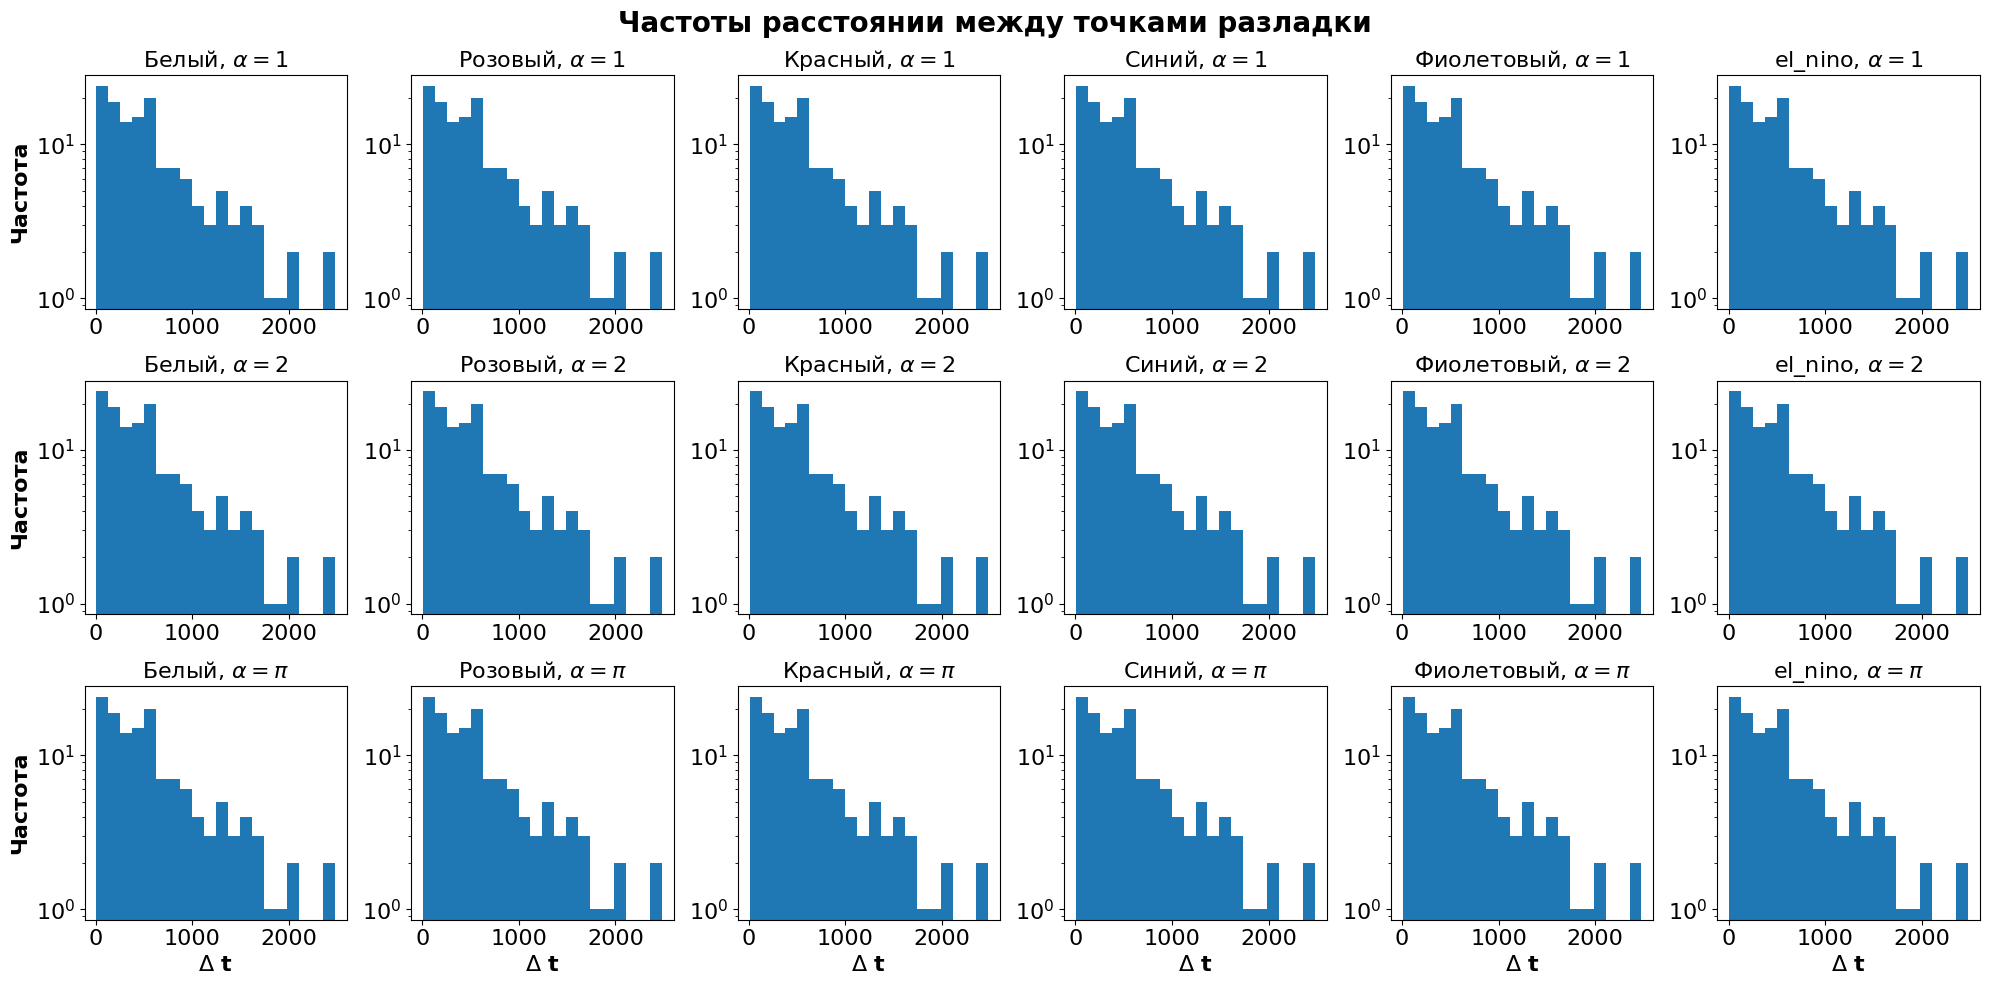

In [7]:
cpd_lda= CPD(method = "LDA")

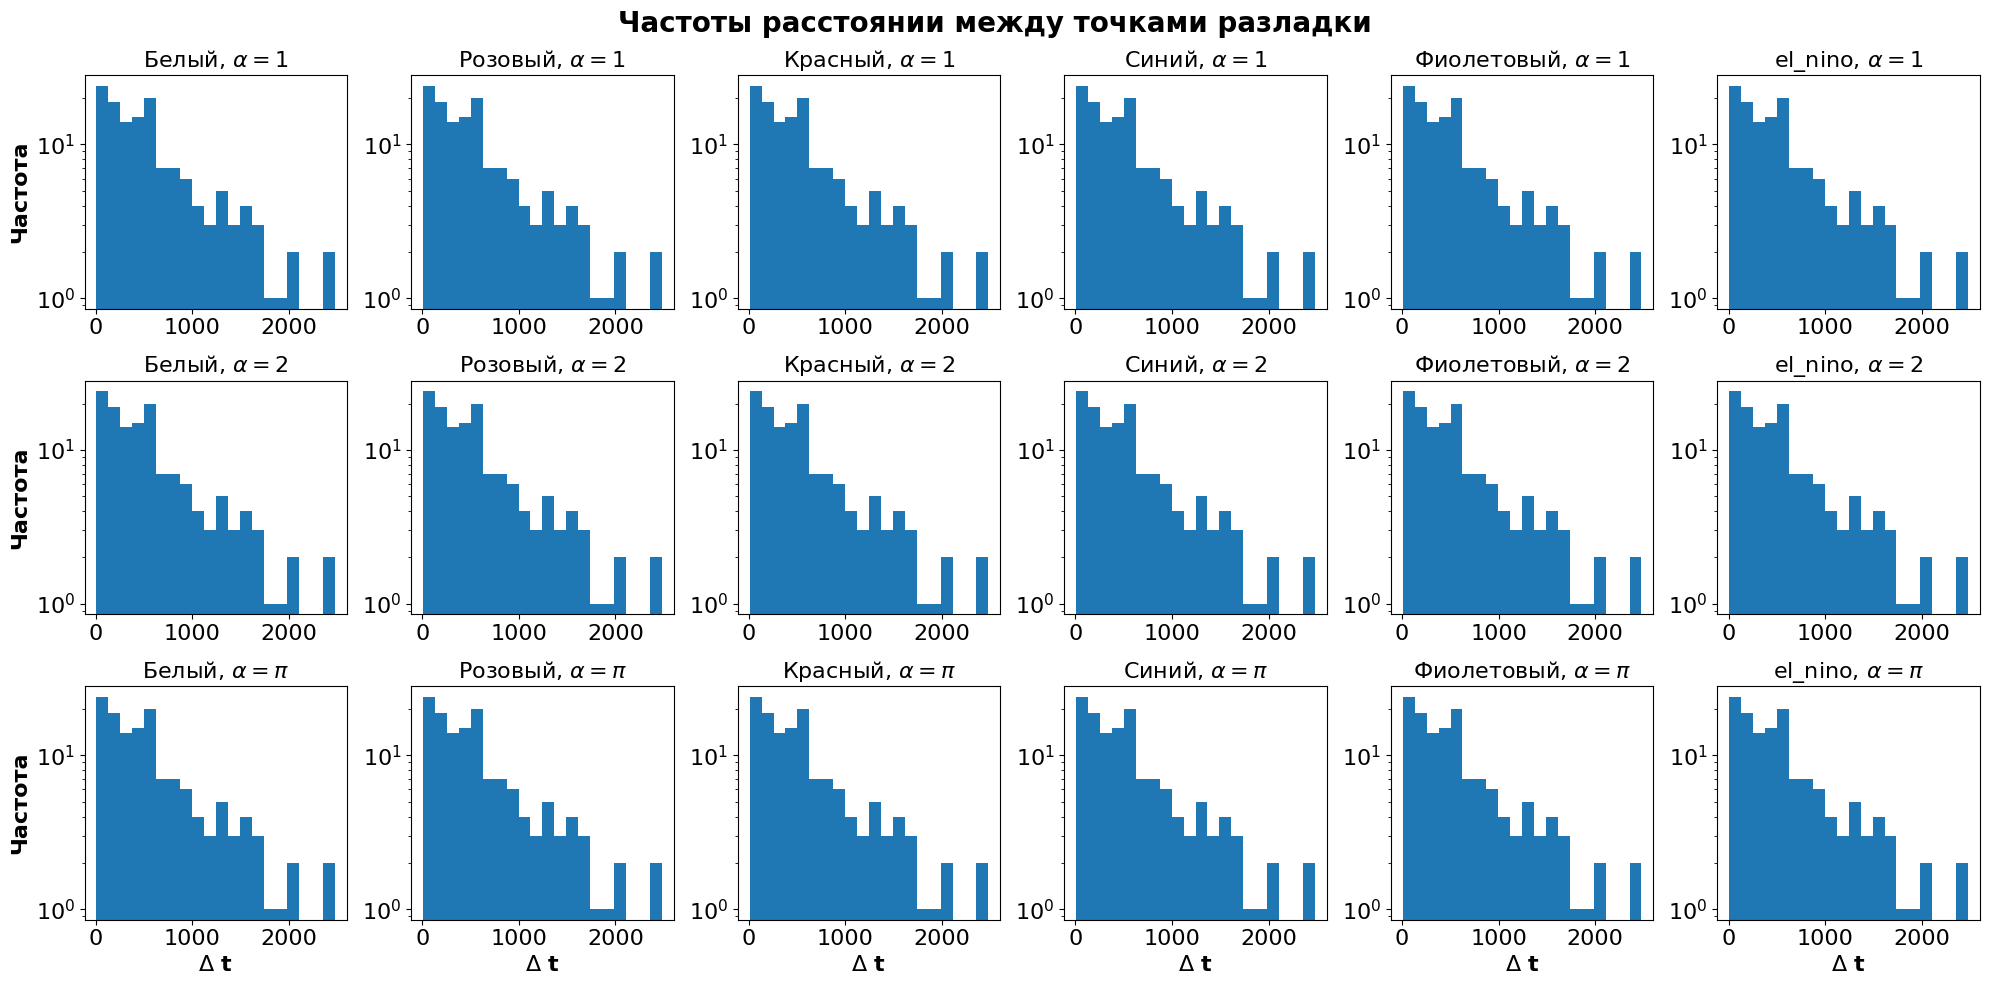

In [8]:
cpd_qda= CPD(method = "QDA")

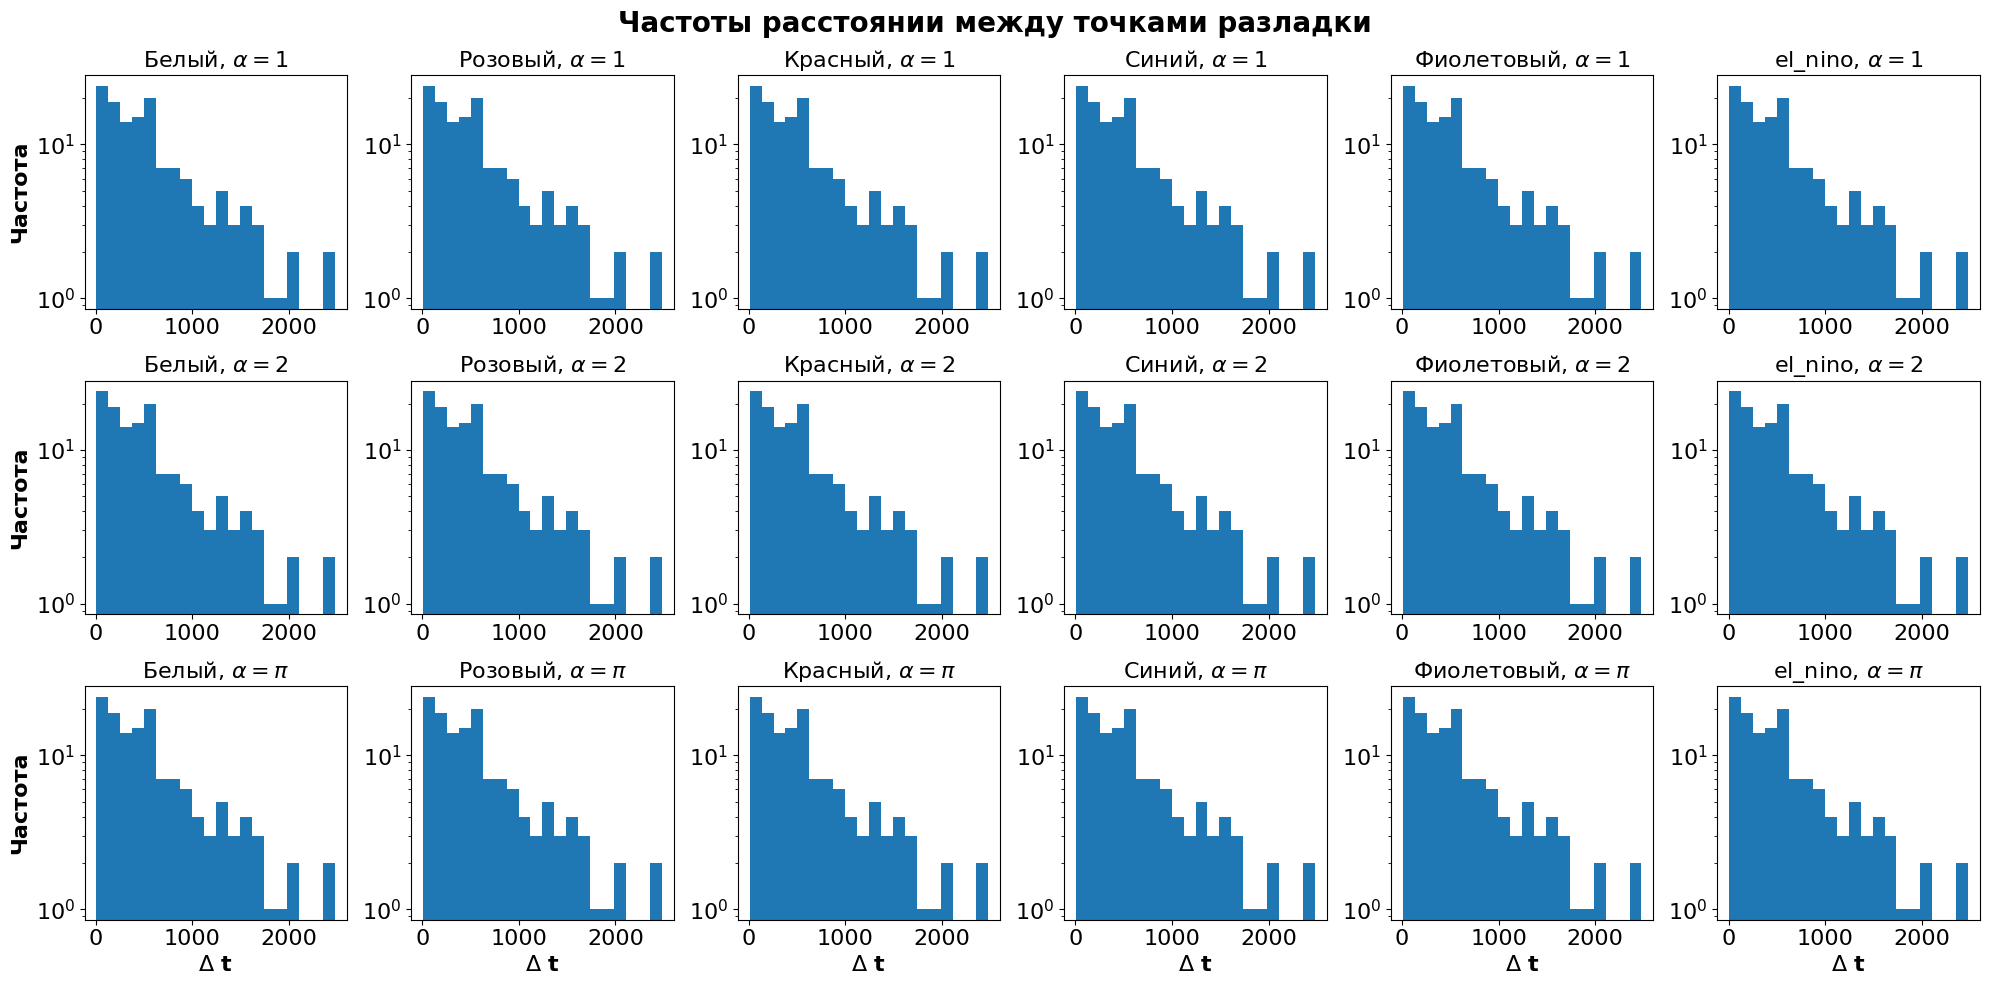

In [9]:
cpd_mlp= CPD(method = "MLP")

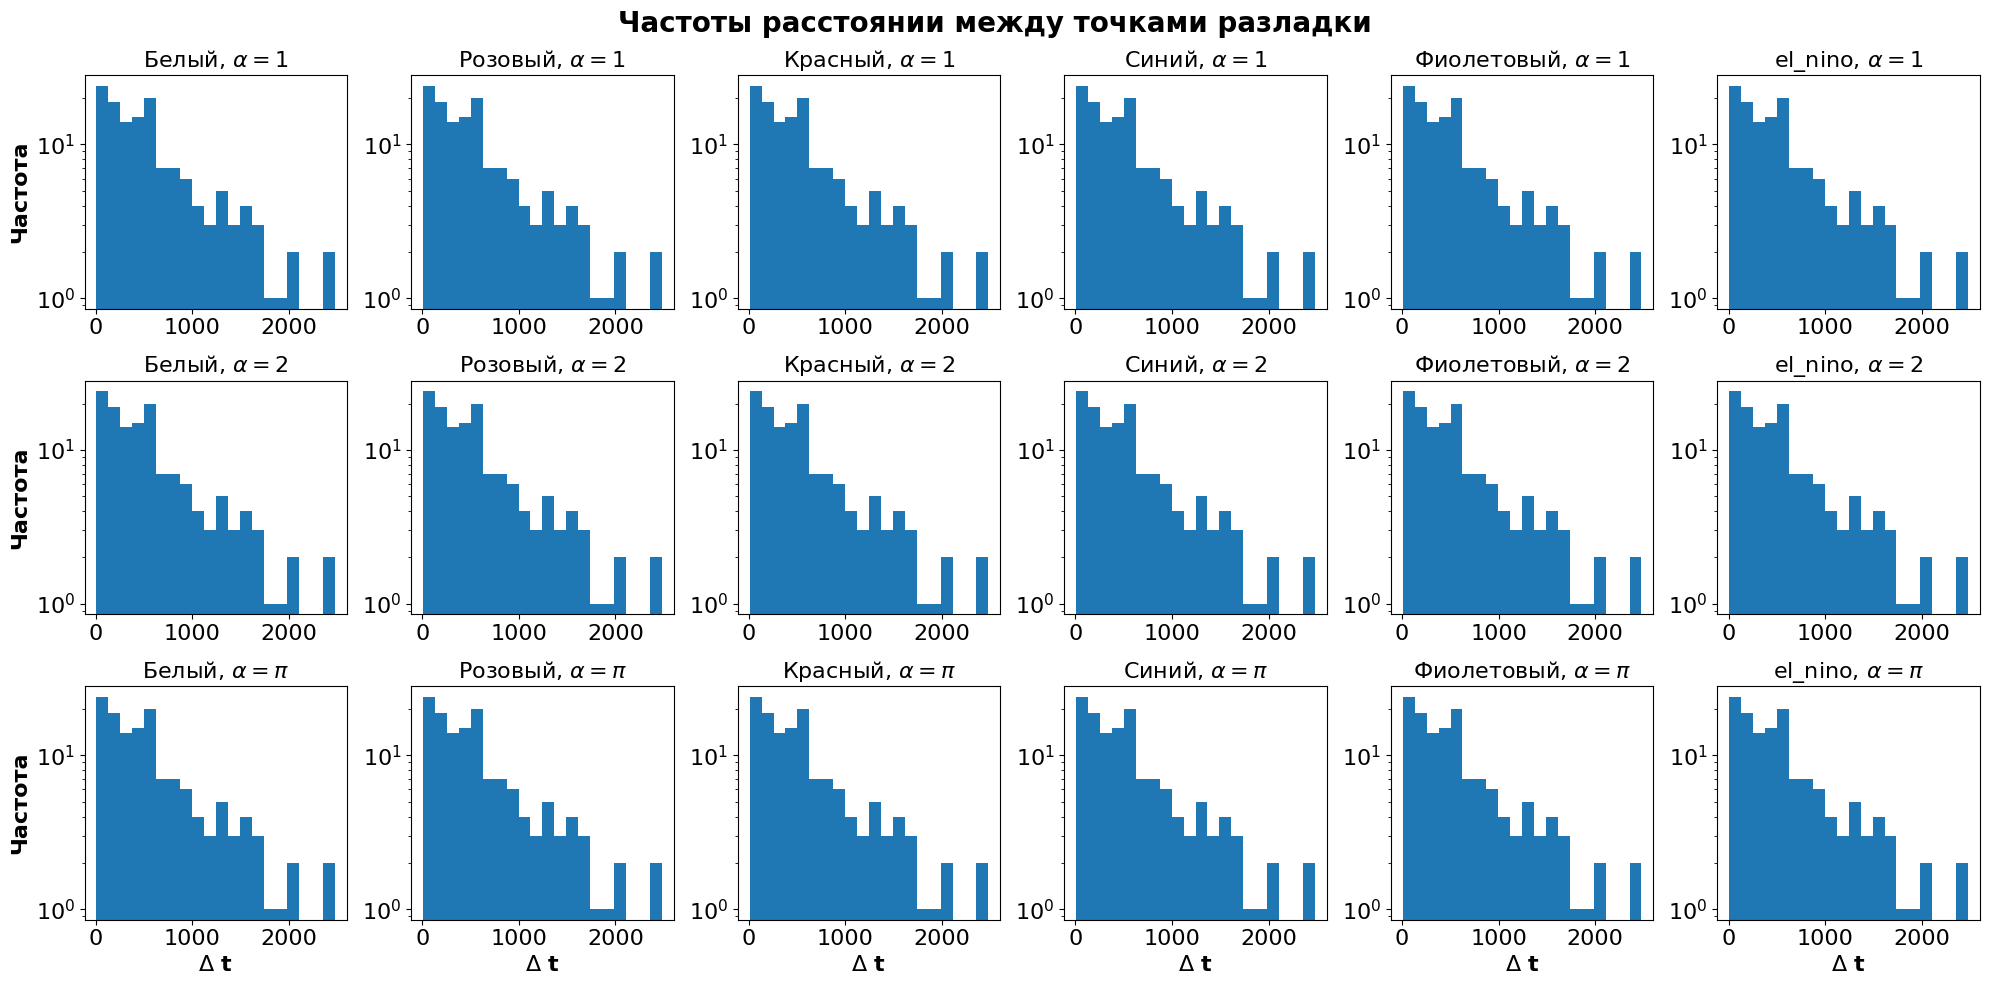

In [10]:
cpd_bns= CPD(method = "Binseg")

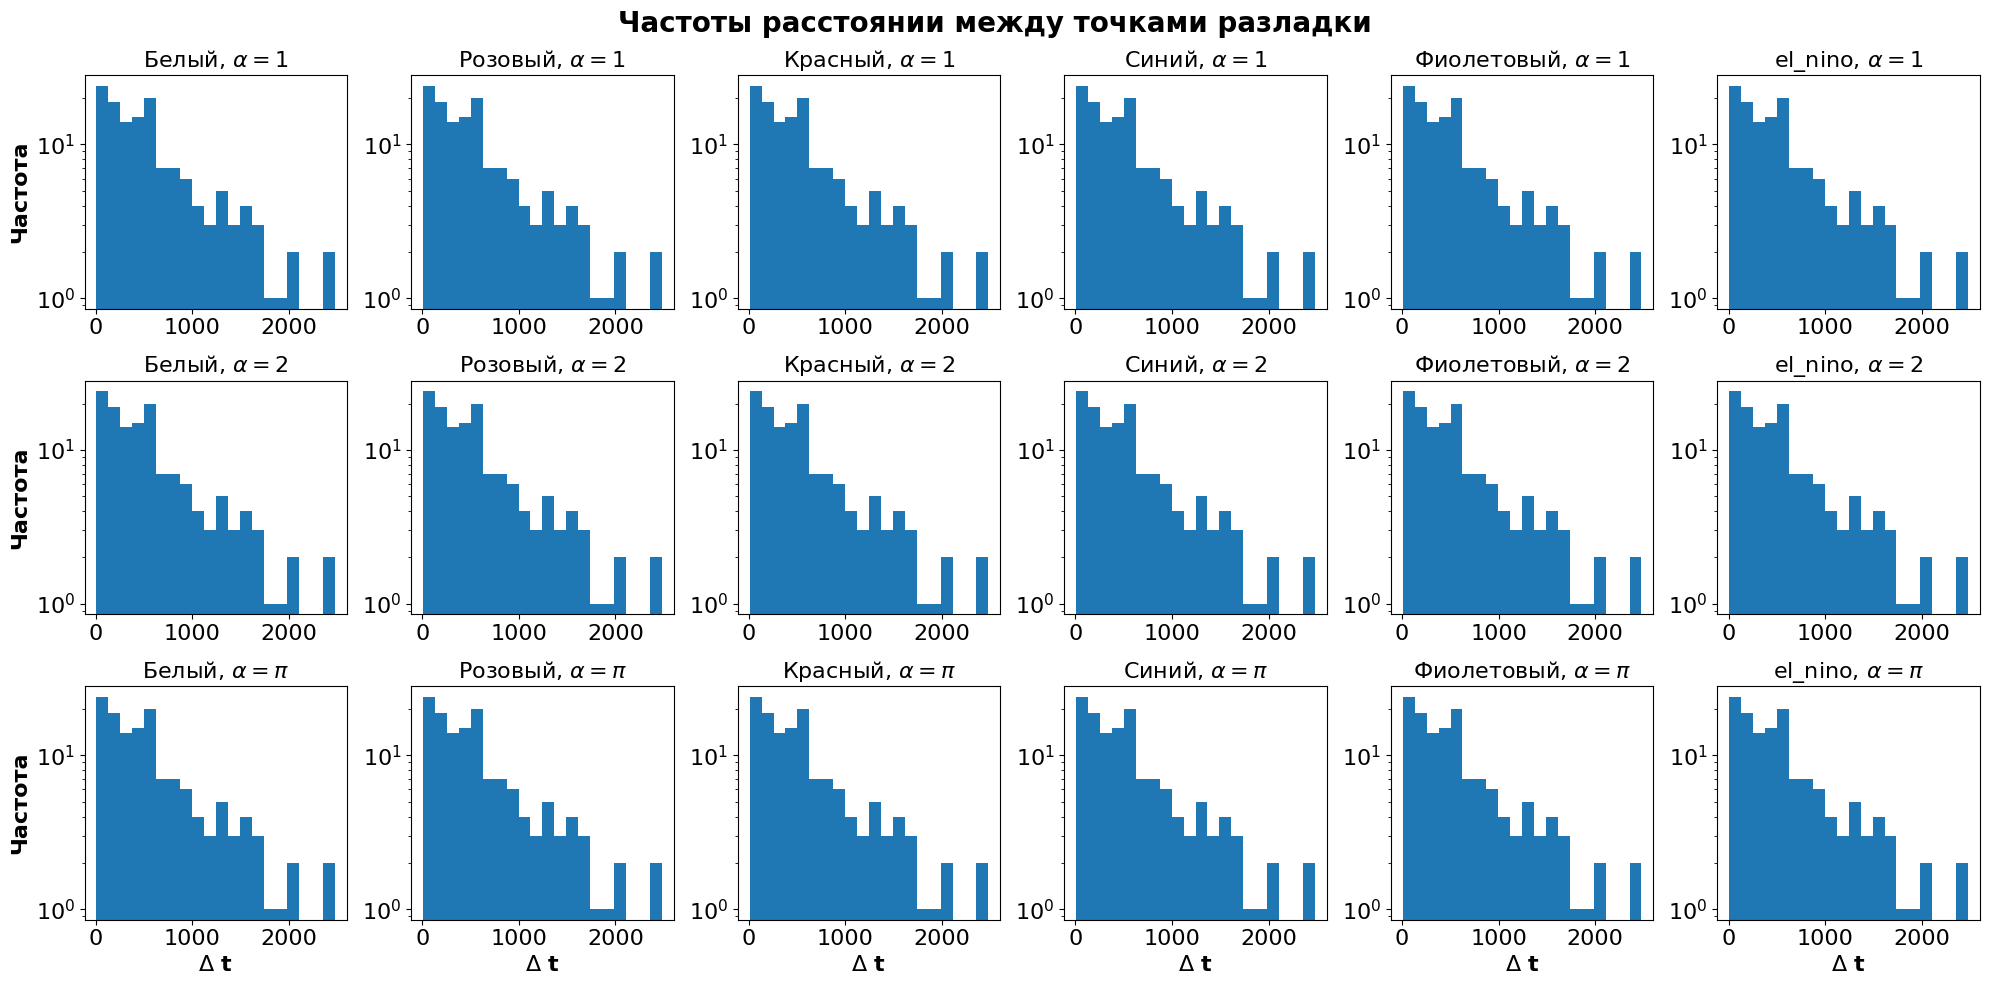

In [11]:
cpd_wnd= CPD(method = "Window")

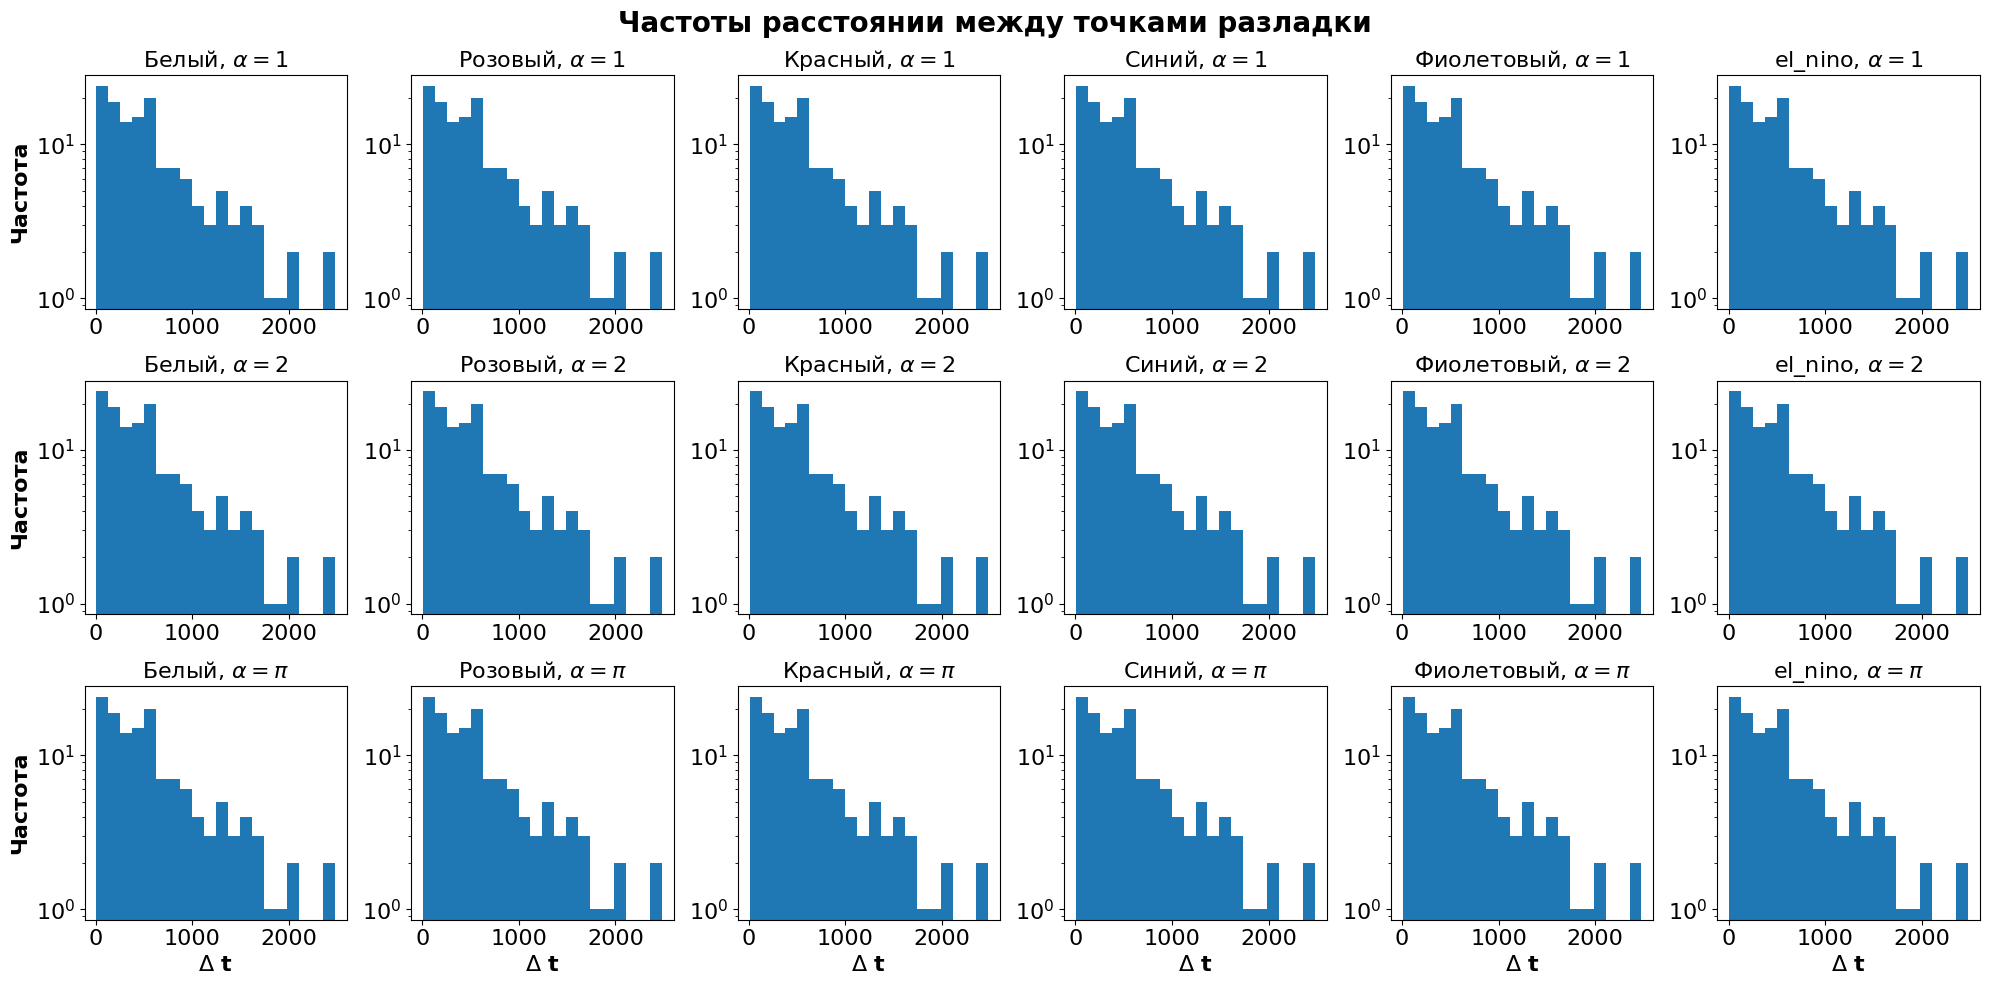

In [12]:
cpd_plt= CPD(method = "Pelt")

##N-BEATS baseline

In [13]:
!pip install torch

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim

class NBeatsBlock(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_size, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, input_size + output_size)
        )
    def forward(self, x):
        out = self.fc(x)
        return out[:, :x.shape[1]], out[:, x.shape[1]:]

class SimpleNBeats(nn.Module):
    def __init__(self, h, num_blocks=2):
        super().__init__()
        self.blocks = nn.ModuleList([NBeatsBlock(h, 1) for _ in range(num_blocks)])

    def forward(self, x):
        residuals = x
        total_forecast = 0

        for block in self.blocks:
            backcast, forecast = block(residuals)
            residuals = residuals - backcast
            total_forecast = total_forecast + forecast

        return total_forecast

In [15]:
synth_cpd_pipeline(method='n-beats')

In [16]:
def run_nbeats_task_results():
    noises = ["White", "Pink", "Red", "Blue"]
    alphas = [1, 2]
    modes = ["binary", "ternary"]

    results = []

    for a in alphas:
        print(f"Testing Alpha: {a}")
        for n in noises:
            gen = np.random.normal if n == "White" else cn.powerlaw_psd_gaussian
            btp = RobustBTP(length=5000, generator=gen, alpha=a, p2=a)
            X = btp.get_data()
            y_all = btp.labels_

            # Simple N-BEATS
            h = 10
            X_auto = np.array([X[i:i+h] for i in range(len(X)-h)])
            y_target = X[h:].reshape(-1, 1)

            model = SimpleNBeats(h)
            opt = torch.optim.Adam(model.parameters(), lr=0.01)
            for _ in range(15):
                opt.zero_grad()
                loss = torch.nn.MSELoss()(model(torch.tensor(X_auto, dtype=torch.float32)), torch.tensor(y_target, dtype=torch.float32))
                loss.backward(); opt.step()

            with torch.no_grad():
                err = np.abs(y_target.flatten() - model(torch.tensor(X_auto, dtype=torch.float32)).numpy().flatten())
                for m in modes:
                    y_pred = np.zeros_like(err)
                    if m == "binary":
                        y_pred[err > np.percentile(err, 95)] = 1
                        y_true = (y_all[h:] > 0).astype(int)
                    else:
                        y_pred[err > np.percentile(err, 92)] = 1
                        y_pred[err > np.percentile(err, 98)] = 2
                        y_true = y_all[h:].astype(int)

                    score = f1_score(y_true, y_pred, average='weighted')
                    results.append({"Noise": n, "Alpha": a, "Labeling": m, "F1": round(score, 4)})

    return pd.DataFrame(results)

final_df = run_nbeats_task_results()
print(final_df)

Testing Alpha: 1
Testing Alpha: 2
    Noise  Alpha Labeling      F1
0   White      1   binary  0.9709
1   White      1  ternary  0.9549
2    Pink      1   binary  0.9725
3    Pink      1  ternary  0.9563
4     Red      1   binary  0.9721
5     Red      1  ternary  0.9559
6    Blue      1   binary  0.9728
7    Blue      1  ternary  0.9568
8   White      2   binary  0.9705
9   White      2  ternary  0.9548
10   Pink      2   binary  0.9730
11   Pink      2  ternary  0.9570
12    Red      2   binary  0.9723
13    Red      2  ternary  0.9562
14   Blue      2   binary  0.9728
15   Blue      2  ternary  0.9568


## N-BEATS experiments

In [17]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import scipy.stats as st
import scipy.signal as signal
import seaborn as sns
import ruptures as rpt
from tqdm.notebook import tqdm
from sklearn.metrics import (
    auc,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)

plt.style.use('seaborn-v0_8-whitegrid')

NOISE_ORDER = ['White', 'Blue', 'Pink', 'Red', 'Green', 'Black']
OPTIONAL_NOISES = ['Violet']


In [18]:
def _standardize_noise(x, eps=1e-12):
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)
    sd = np.std(x)
    if sd < eps:
        return np.zeros_like(x)
    return x / sd


def _pink_voss_mccartney(n, rng, n_rows=16):
    rows = rng.normal(size=(n_rows, n))
    out = np.zeros(n)
    values = rng.normal(size=n_rows)
    for t in range(n):
        if t == 0:
            refresh = np.ones(n_rows, dtype=bool)
        else:
            refresh_count = min(n_rows, int((t & -t).bit_length()))
            refresh = np.zeros(n_rows, dtype=bool)
            refresh[:refresh_count] = True
        values[refresh] = rows[refresh, t]
        out[t] = values.sum()
    return out


def generate_colored_noise(noise_type, n, rng):
    noise_type = noise_type.title()
    white = rng.normal(size=n)

    if noise_type == 'White':
        xi = white
    elif noise_type == 'Blue':
        xi = np.diff(np.r_[white[0], white])
    elif noise_type == 'Pink':
        xi = _pink_voss_mccartney(n, rng)
    elif noise_type == 'Red':
        xi = np.cumsum(white)
    elif noise_type == 'Green':
        sos = signal.butter(4, [0.2, 0.4], btype='bandpass', output='sos')
        xi = signal.sosfiltfilt(sos, white) if n > 30 else signal.sosfilt(sos, white)
    elif noise_type == 'Black':
        xi = 0.03 * rng.normal(size=n)
        impulse_mask = rng.random(n) < 0.015
        xi[impulse_mask] += rng.choice([-1, 1], impulse_mask.sum()) * rng.uniform(4, 8, impulse_mask.sum())
    elif noise_type == 'Violet':
        xi = np.diff(np.r_[white[0], white[0], white], n=2)
    else:
        raise ValueError(f"Unknown noise_type={noise_type!r}. Use {NOISE_ORDER + OPTIONAL_NOISES}.")

    return _standardize_noise(xi)


def generate_btp_series(
    n=1000,
    mu_seg=60,
    alpha=1.0,
    noise_type='White',
    seed=None,
    levels=(-1.0, 1.0),
):

    rng = np.random.default_rng(seed)
    p_switch = 1.0 / mu_seg

    states = []
    cps = []
    state = 0
    t = 0
    while t < n:
        seg_len = int(rng.geometric(p_switch))
        end = min(n, t + seg_len)
        states.extend([state] * (end - t))
        t = end
        if t < n:
            cps.append(t)
            state = 1 - state

    states = np.asarray(states[:n], dtype=int)
    latent = np.where(states == 0, levels[0], levels[1]).astype(float)
    xi = generate_colored_noise(noise_type, n, rng)
    x = latent + alpha * xi

    return {
        'x': x,
        'states': states,
        'latent': latent,
        'noise': xi,
        'change_points': np.asarray(cps, dtype=int),
        'noise_type': noise_type.title(),
        'alpha': alpha,
        'mu_seg': mu_seg,
    }


def plot_btp_examples(noise_types=NOISE_ORDER, n=1000, mu_seg=60, alpha=1.0, seed=7):
    fig, axes = plt.subplots(len(noise_types), 1, figsize=(14, 2.2 * len(noise_types)), sharex=True)
    if len(noise_types) == 1:
        axes = [axes]
    for ax, noise in zip(axes, noise_types):
        sample = generate_btp_series(n=n, mu_seg=mu_seg, alpha=alpha, noise_type=noise, seed=seed)
        ax.plot(sample['x'], color='black', lw=0.9, label='Observed $X_t$')
        ax.plot(sample['latent'], color='tab:orange', lw=1.2, alpha=0.8, label='Latent mean $L(s_t)$')
        for cp in sample['change_points']:
            ax.axvline(cp, color='tab:green', alpha=0.25, lw=1)
        ax.set_title(f"{noise} BTP noise")
    axes[0].legend(loc='upper right')
    axes[-1].set_xlabel('t')
    plt.tight_layout()
    plt.savefig('btp_generation_examples.jpeg', dpi=300)
    plt.show()


In [19]:
def make_supervised_windows(x, h):
    x = np.asarray(x, dtype=float)
    X = np.array([x[i:i+h] for i in range(len(x) - h)], dtype=np.float32)
    y = x[h:].reshape(-1, 1).astype(np.float32)
    return X, y


def train_nbeats_detector(x, h=10, epochs=40, lr=1e-2, seed=123, batch_size=None, verbose=False):
    torch.manual_seed(seed)
    np.random.seed(seed)

    X, y = make_supervised_windows(x, h)
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.float32)

    model = SimpleNBeats(h)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = torch.nn.MSELoss()

    model.train()
    if batch_size is None or batch_size >= len(X_t):
        for epoch in range(epochs):
            opt.zero_grad()
            loss = crit(model(X_t), y_t)
            loss.backward()
            opt.step()
            if verbose and (epoch + 1) % 10 == 0:
                print(f"epoch={epoch+1:03d}, loss={loss.item():.4f}")
    else:
        ds = torch.utils.data.TensorDataset(X_t, y_t)
        loader = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=True)
        for epoch in range(epochs):
            for xb, yb in loader:
                opt.zero_grad()
                loss = crit(model(xb), yb)
                loss.backward()
                opt.step()

    model.eval()
    with torch.no_grad():
        forecast = model(X_t).cpu().numpy().reshape(-1)
    target = y.reshape(-1)
    errors = np.abs(target - forecast)
    return model, forecast, target, errors


def shifted_change_points(change_points, h, score_len):
    return np.asarray([cp - h for cp in change_points if 0 <= cp - h < score_len], dtype=int)


def labels_from_change_points(change_points, score_len, tolerance=0):
    y = np.zeros(score_len, dtype=int)
    for cp in change_points:
        lo = max(0, int(cp) - tolerance)
        hi = min(score_len, int(cp) + tolerance + 1)
        y[lo:hi] = 1
    return y


def predictions_from_threshold(errors, threshold):
    return (np.asarray(errors) > threshold).astype(int)


def point_metrics(errors, true_cp_idx, threshold_pct=95, tolerance=2):
    threshold = np.percentile(errors, threshold_pct)
    y_true = labels_from_change_points(true_cp_idx, len(errors), tolerance=tolerance)
    y_pred = predictions_from_threshold(errors, threshold)

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    precision_curve, recall_curve, _ = precision_recall_curve(y_true, errors)
    pr_auc = auc(recall_curve, precision_curve)
    roc_auc = roc_auc_score(y_true, errors) if len(np.unique(y_true)) == 2 else np.nan

    true_bkps = sorted(true_cp_idx.tolist() + [len(errors)])
    pred_bkps = sorted(np.where(y_pred == 1)[0].tolist() + [len(errors)])
    try:
        rpt_precision, rpt_recall = rpt.metrics.precision_recall(true_bkps, pred_bkps, margin=tolerance)
        rpt_f1 = 2 * rpt_precision * rpt_recall / (rpt_precision + rpt_recall) if (rpt_precision + rpt_recall) else 0.0
    except Exception:
        rpt_precision, rpt_recall, rpt_f1 = np.nan, np.nan, np.nan

    return {
        'ThresholdPct': threshold_pct,
        'Threshold': threshold,
        'Tolerance': tolerance,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'PR_AUC': pr_auc,
        'ROC_AUC': roc_auc,
        'Ruptures_Precision': rpt_precision,
        'Ruptures_Recall': rpt_recall,
        'Ruptures_F1': rpt_f1,
        'N_True_CP': len(true_cp_idx),
        'N_Predicted': int(y_pred.sum()),
    }


def fit_nbeats_once(noise_type, n=1000, mu_seg=60, alpha=1.0, h=10, epochs=40, lr=1e-2, seed=123):
    series = generate_btp_series(n=n, mu_seg=mu_seg, alpha=alpha, noise_type=noise_type, seed=seed)
    model, forecast, target, errors = train_nbeats_detector(series['x'], h=h, epochs=epochs, lr=lr, seed=seed)
    cp_idx = shifted_change_points(series['change_points'], h=h, score_len=len(errors))
    return series, model, forecast, target, errors, cp_idx


In [20]:
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns
import ruptures as rpt
from tqdm.notebook import tqdm
from sklearn.metrics import precision_recall_curve, auc, roc_auc_score


plt.style.use('seaborn-v0_8-whitegrid')
NOISE_COLORS = {'White': '#95a5a6', 'Blue': '#3498db', 'Pink': '#e84393',
                'Red': '#c0392b', 'Green': '#27ae60', 'Black': '#2c3e50', 'Violet': '#8e44ad'}

def point_metrics_robust(errors, true_cp_idx, threshold_pct=95, tolerance=2):
    """
    Calculates metrics using Ruptures margin-based matching as the PRIMARY metric.
    """
    threshold = np.percentile(errors, threshold_pct)
    y_pred = (np.asarray(errors) > threshold).astype(int)


    true_bkps = sorted(true_cp_idx.tolist() + [len(errors)])
    pred_bkps = sorted(np.where(y_pred == 1)[0].tolist() + [len(errors)])

    try:
        p, r = rpt.metrics.precision_recall(true_bkps, pred_bkps, margin=tolerance)
        f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
    except:
        p, r, f1 = 0.0, 0.0, 0.0


    y_true_widened = np.zeros(len(errors), dtype=int)
    for cp in true_cp_idx:
        lo, hi = max(0, cp - tolerance), min(len(errors), cp + tolerance + 1)
        y_true_widened[lo:hi] = 1

    precision_curve, recall_curve, _ = precision_recall_curve(y_true_widened, errors)
    pr_auc = auc(recall_curve, precision_curve)
    roc_auc = roc_auc_score(y_true_widened, errors) if len(np.unique(y_true_widened)) == 2 else 0.5

    return {
        'Precision': p, 'Recall': r, 'F1': f1,
        'PR_AUC': pr_auc, 'ROC_AUC': roc_auc,
        'Threshold': threshold
    }

###1&2. Core detection performance

h=10,w=2, and threshold 95

noises:   0%|          | 0/6 [00:00<?, ?it/s]

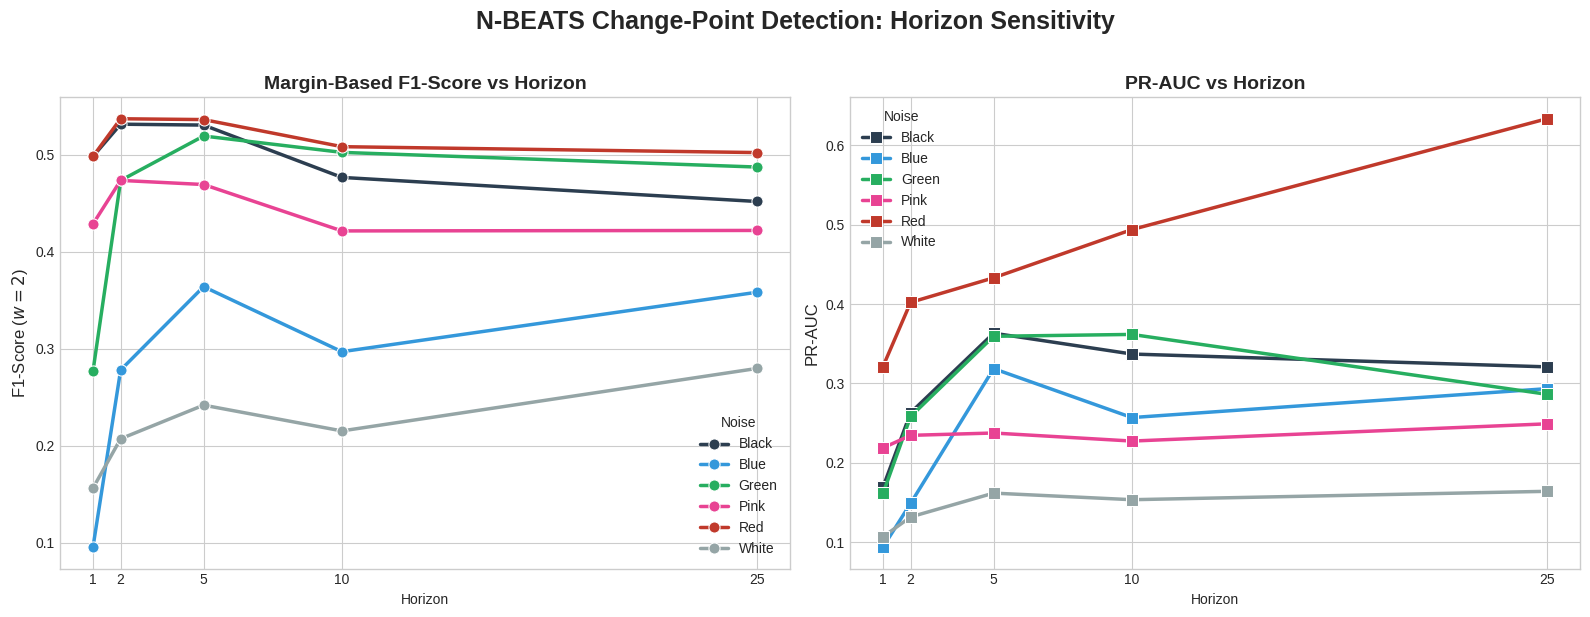


 Table (h=10, w=2, 95th Pct)


,F1,PR_AUC,Precision,Recall,ROC_AUC
Noise,,,,,
Black,0.477,0.337,0.324,0.941,0.782
Blue,0.297,0.257,0.202,0.585,0.694
Green,0.502,0.362,0.342,0.989,0.680
Pink,0.421,0.227,0.286,0.836,0.635
Red,0.508,0.494,0.346,1.000,0.718
White,0.215,0.154,0.146,0.430,0.622


In [21]:
def experiment_horizon_and_core_robust():
    noises = ['White', 'Blue', 'Pink', 'Red', 'Green', 'Black']
    horizons = [1, 2, 5, 10, 25]
    n_runs = 5

    rows = []
    for noise in tqdm(noises, desc='noises'):
        for h in horizons:
            for run in range(n_runs):
                seed = 1000 * run + h * 10
                _, _, _, _, errors, cp_idx = fit_nbeats_once(
                    noise, n=2000, mu_seg=60, alpha=1.04, h=h, epochs=20, lr=1e-2, seed=seed)

                metrics = point_metrics_robust(errors, cp_idx, threshold_pct=95, tolerance=2)
                metrics.update({'Noise': noise, 'Horizon': h, 'Run': run})
                rows.append(metrics)

    df = pd.DataFrame(rows)
    summary = df.groupby(['Noise', 'Horizon'], as_index=False)[['F1', 'PR_AUC', 'Precision', 'Recall', 'ROC_AUC']].mean()

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('N-BEATS Change-Point Detection: Horizon Sensitivity', fontsize=18, fontweight='bold', y=1.02)

    sns.lineplot(data=summary, x='Horizon', y='F1', hue='Noise', palette=NOISE_COLORS,
                 marker='o', linewidth=2.5, markersize=8, ax=axes[0])
    axes[0].set_title('Margin-Based F1-Score vs Horizon', fontsize=14, fontweight='bold')
    axes[0].set_xticks(horizons)
    axes[0].set_ylabel('F1-Score ($w=2$)', fontsize=12)

    sns.lineplot(data=summary, x='Horizon', y='PR_AUC', hue='Noise', palette=NOISE_COLORS,
                 marker='s', linewidth=2.5, markersize=8, ax=axes[1])
    axes[1].set_title('PR-AUC vs Horizon', fontsize=14, fontweight='bold')
    axes[1].set_xticks(horizons)
    axes[1].set_ylabel('PR-AUC', fontsize=12)

    plt.tight_layout()
    plt.savefig('nbeats_horizon_sensitivity_robust.jpeg', dpi=300, bbox_inches='tight')
    plt.show()

    print("\n Table (h=10, w=2, 95th Pct)")
    core_table = summary[summary['Horizon'] == 10].drop(columns=['Horizon']).set_index('Noise').round(3)
    display(core_table)

experiment_horizon_and_core_robust()

### 3&4. Threshold and precision-recall

sensitivity:   0%|          | 0/3 [00:00<?, ?it/s]

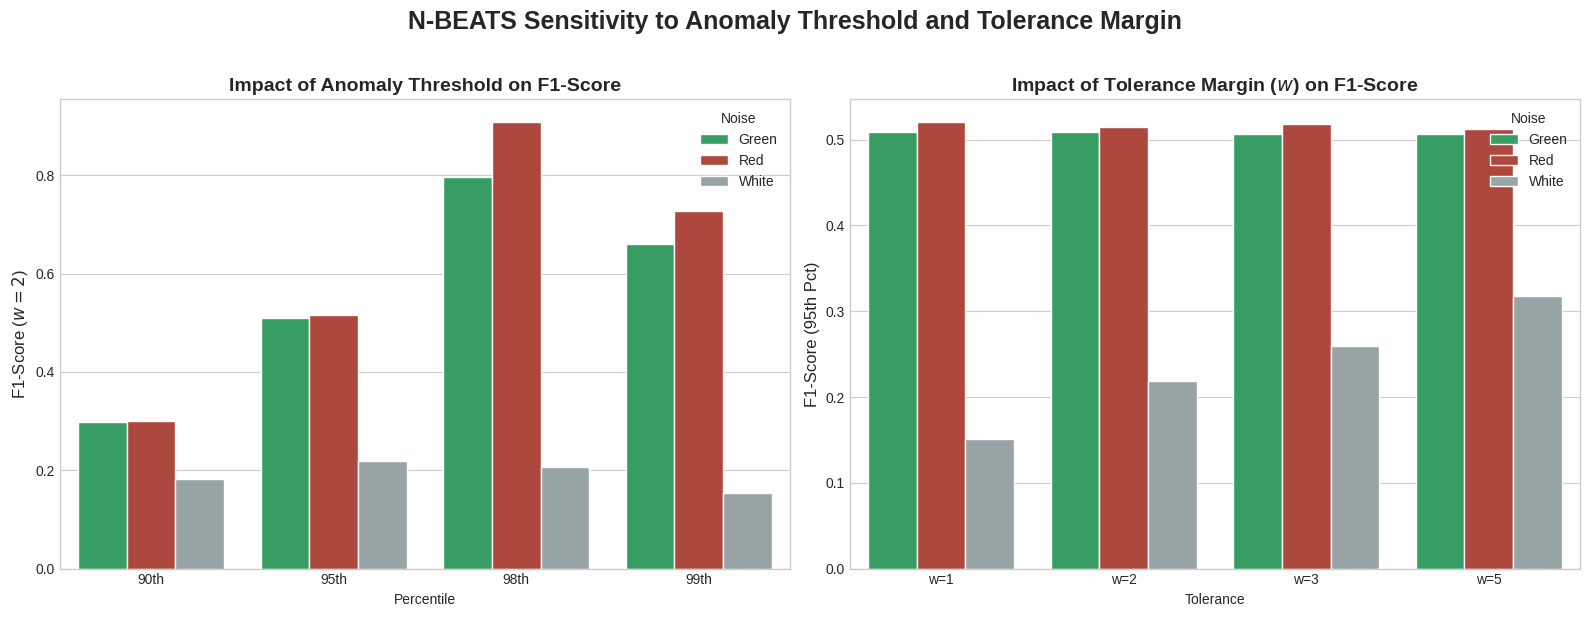

In [22]:
def experiment_threshold_and_tolerance_robust():
    noises = ['White', 'Red', 'Green']
    n_runs = 5
    h = 10

    thresh_rows, tol_rows = [], []

    for noise in tqdm(noises, desc='sensitivity'):
        for run in range(n_runs):
            seed = 4200 + run
            _, _, _, _, errors, cp_idx = fit_nbeats_once(
                noise, n=2000, mu_seg=60, alpha=1.04, h=h, epochs=20, lr=1e-2, seed=seed)

            for pct in [90, 95, 98, 99]:
                m = point_metrics_robust(errors, cp_idx, threshold_pct=pct, tolerance=2)
                thresh_rows.append({'Noise': noise, 'Percentile': f"{pct}th", 'F1': m['F1']})

            for w in [1, 2, 3, 5]:
                m = point_metrics_robust(errors, cp_idx, threshold_pct=95, tolerance=w)
                tol_rows.append({'Noise': noise, 'Tolerance': f"w={w}", 'F1': m['F1']})

    df_t = pd.DataFrame(thresh_rows).groupby(['Noise', 'Percentile'], as_index=False).mean()
    df_w = pd.DataFrame(tol_rows).groupby(['Noise', 'Tolerance'], as_index=False).mean()

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('N-BEATS Sensitivity to Anomaly Threshold and Tolerance Margin', fontsize=18, fontweight='bold', y=1.02)

    sns.barplot(data=df_t, x='Percentile', y='F1', hue='Noise', palette=NOISE_COLORS, ax=axes[0], edgecolor='white')
    axes[0].set_title('Impact of Anomaly Threshold on F1-Score', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('F1-Score ($w=2$)', fontsize=12)

    sns.barplot(data=df_w, x='Tolerance', y='F1', hue='Noise', palette=NOISE_COLORS, ax=axes[1], edgecolor='white')
    axes[1].set_title('Impact of Tolerance Margin ($w$) on F1-Score', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('F1-Score (95th Pct)', fontsize=12)

    plt.tight_layout()
    plt.savefig('nbeats_threshold_tolerance_bars.jpeg', dpi=300, bbox_inches='tight')
    plt.show()

experiment_threshold_and_tolerance_robust()

### 5. Gap distribution analysis

`Δt` and Normal, Student-t, and Cauchy fits.


ggaps:   0%|          | 0/6 [00:00<?, ?it/s]

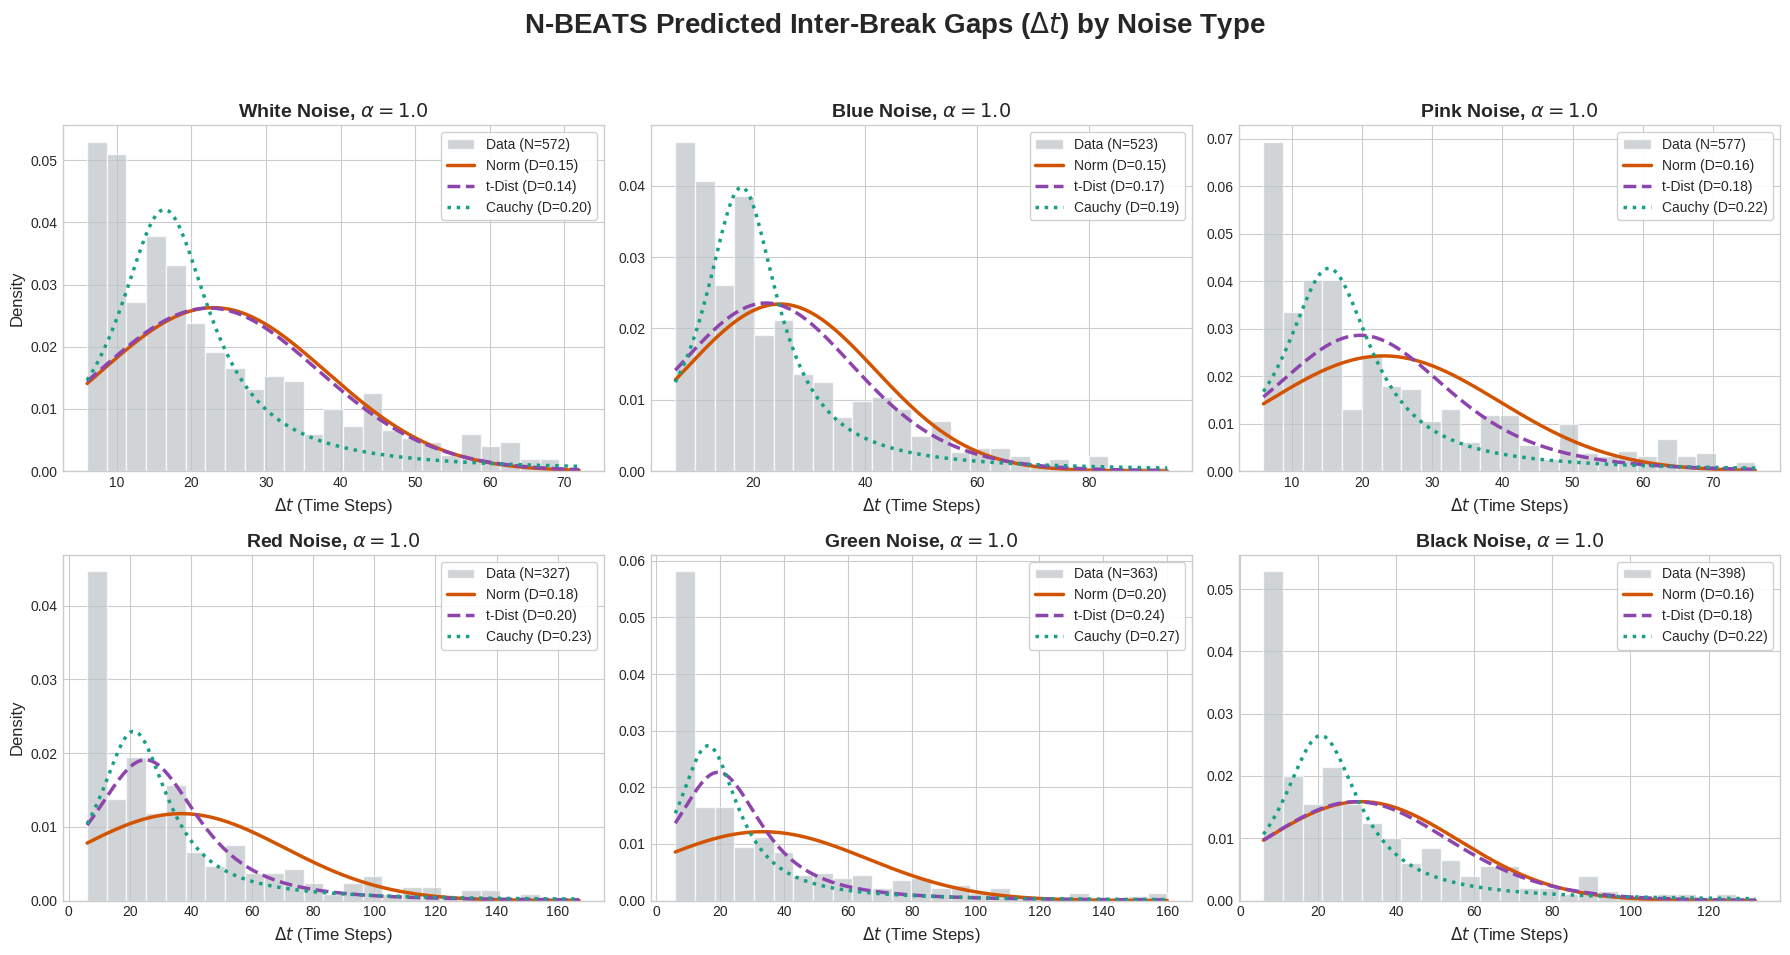

In [23]:
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

def get_robust_anomaly_gaps(errors, threshold_pct=95, cluster_tolerance=5):

    threshold = np.percentile(errors, threshold_pct)
    pred_idx = np.where(errors > threshold)[0]

    if len(pred_idx) < 2:
        return np.array([])

    events = [pred_idx[0]]
    for idx in pred_idx[1:]:
        if idx - events[-1] > cluster_tolerance:
            events.append(idx)

    gaps = np.diff(events)
    return gaps

def experiment_gap_distribution_robust(
    noise_types=NOISE_ORDER,
    n_runs=15,
    n=1000,
    mu_seg=60,
    alpha=1.0,
    h=10,
    threshold_pct=95,
    epochs=20,
    lr=1e-2,
    seed0=6400,
):
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.ravel()
    fig.suptitle('N-BEATS Predicted Inter-Break Gaps ($\Delta t$) by Noise Type',
                 fontsize=20, fontweight='bold', y=0.98)

    fit_rows = []

    for i, noise in enumerate(tqdm(noise_types, desc="ggaps")):
        ax = axes[i]
        all_gaps = []

        for run in range(n_runs):
            seed = seed0 + 31 * i + run
            _, _, _, _, errors, _ = fit_nbeats_once(
                noise, n=n, mu_seg=mu_seg, alpha=alpha, h=h, epochs=epochs, lr=lr, seed=seed
            )
            gaps = get_robust_anomaly_gaps(errors, threshold_pct=threshold_pct, cluster_tolerance=5)
            all_gaps.extend(gaps)

        all_gaps = np.array(all_gaps)


        if len(all_gaps) > 0:
            upper_limit = np.percentile(all_gaps, 98)
            all_gaps = all_gaps[all_gaps <= upper_limit]

        if len(all_gaps) < 10:
            ax.set_title(f'{noise} Noise\nInsufficient Data', color='red')
            continue

        ax.hist(all_gaps, bins=25, density=True, alpha=0.7, color='#bdc3c7', edgecolor='white', label=f'Data (N={len(all_gaps)})')

        ax.set_title(f'{noise} Noise, $\\alpha={alpha}$', fontsize=14, fontweight='bold')
        ax.set_xlabel('$\Delta t$ (Time Steps)', fontsize=12)
        if i % 3 == 0:
            ax.set_ylabel('Density', fontsize=12)


        x = np.linspace(max(0, all_gaps.min()), all_gaps.max(), 250)

        try:
            mu, std = st.norm.fit(all_gaps)
            ax.plot(x, st.norm.pdf(x, mu, std), color='#d35400', lw=2.5,
                    label=f'Norm (D={st.kstest(all_gaps, "norm", args=(mu, std)).statistic:.2f})')

            df, loc, scale = st.t.fit(all_gaps)
            ax.plot(x, st.t.pdf(x, df, loc, scale), color='#8e44ad', lw=2.5, linestyle='--',
                    label=f't-Dist (D={st.kstest(all_gaps, "t", args=(df, loc, scale)).statistic:.2f})')

            c_loc, c_scale = st.cauchy.fit(all_gaps)
            ax.plot(x, st.cauchy.pdf(x, c_loc, c_scale), color='#16a085', lw=2.5, linestyle=':',
                    label=f'Cauchy (D={st.kstest(all_gaps, "cauchy", args=(c_loc, c_scale)).statistic:.2f})')
        except Exception as e:
            print(f"Skipping fits for {noise} due to error: {e}")

        ax.legend(fontsize=10, loc='upper right', frameon=True, framealpha=0.9)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('nbeats_btp_gap_distribution.jpeg', dpi=300, bbox_inches='tight')
    plt.show()

experiment_gap_distribution_robust(noise_types=['White', 'Blue', 'Pink', 'Red', 'Green', 'Black'])

### 6. Visual proof

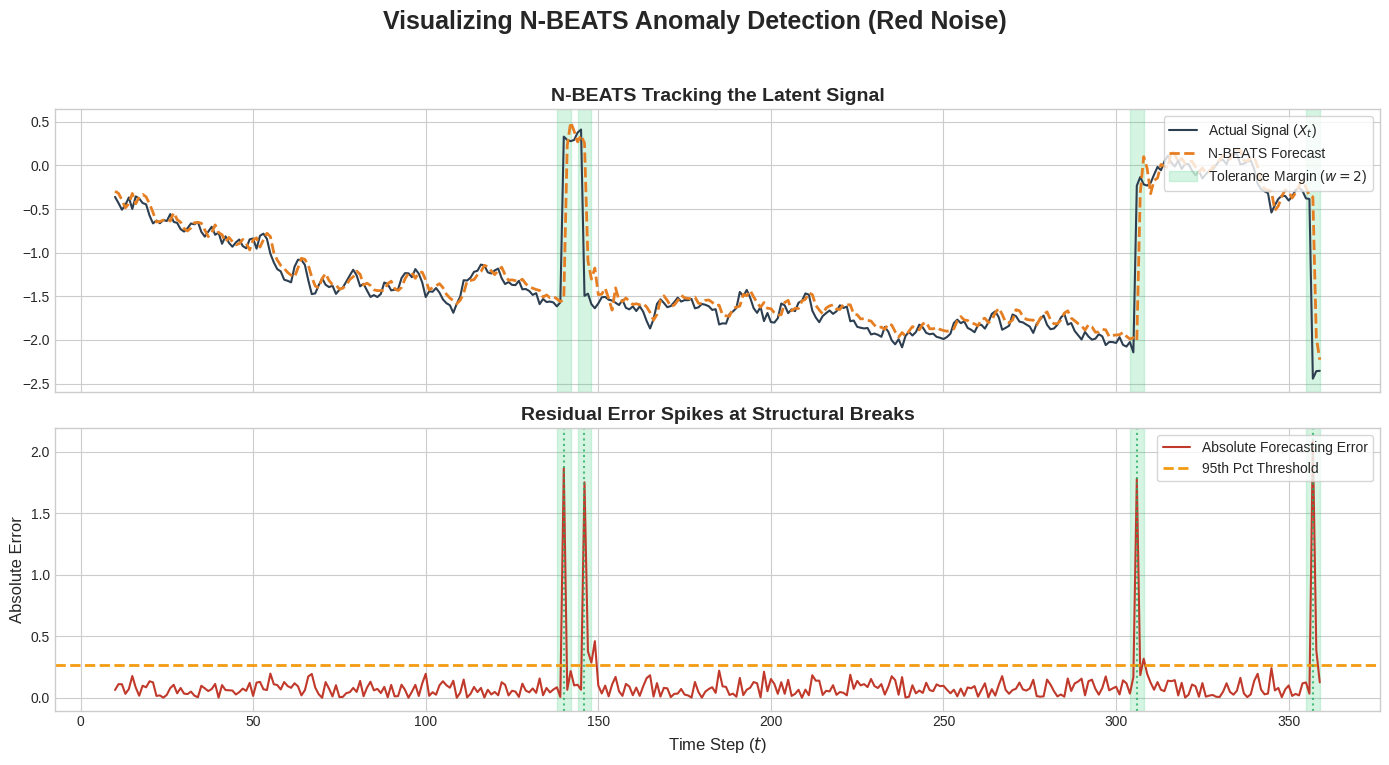

In [24]:
def plot_qualitative_residual_proof_robust():
    noise_type = 'Red'
    h, w = 10, 2

    series, _, forecast, target, errors, cp_idx = fit_nbeats_once(
        noise_type, n=1500, mu_seg=60, alpha=1.04, h=h, epochs=30, lr=1e-2, seed=777)

    threshold = np.percentile(errors, 95)
    plot_len = 350

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    fig.suptitle(f'Visualizing N-BEATS Anomaly Detection ({noise_type} Noise)', fontsize=18, fontweight='bold', y=0.98)

    time_axis = np.arange(h, h + len(target))
    keep = time_axis < (h + plot_len)

    axes[0].plot(time_axis[keep], target[keep], color='#2c3e50', lw=1.5, label='Actual Signal ($X_t$)')
    axes[0].plot(time_axis[keep], forecast[keep], color='#e67e22', lw=2, ls='--', label='N-BEATS Forecast')
    axes[0].set_title('N-BEATS Tracking the Latent Signal', fontsize=14, fontweight='bold')
    axes[0].legend(loc='upper right', frameon=True)

    axes[1].plot(time_axis[keep], errors[keep], color='#c0392b', lw=1.5, label='Absolute Forecasting Error')
    axes[1].axhline(threshold, color='#f39c12', ls='--', lw=2, label='95th Pct Threshold')
    axes[1].set_title('Residual Error Spikes at Structural Breaks', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Time Step ($t$)', fontsize=12)
    axes[1].set_ylabel('Absolute Error', fontsize=12)

    for cp in cp_idx:
        if cp + h < h + plot_len:
            axes[0].axvspan(cp+h-w, cp+h+w, color='#2ecc71', alpha=0.2, label='Tolerance Margin ($w=2$)' if cp==cp_idx[0] else "")
            axes[1].axvspan(cp+h-w, cp+h+w, color='#2ecc71', alpha=0.2)

            axes[1].axvline(cp+h, color='#27ae60', alpha=0.8, lw=1.5, ls=':')

    axes[0].legend(loc='upper right', frameon=True)
    axes[1].legend(loc='upper right', frameon=True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('nbeats_btp_qualitative_residual_proof.jpeg', dpi=300)
    plt.show()

plot_qualitative_residual_proof_robust()

###Signed Three-Class Detection and Best Fit

Signed:   0%|          | 0/6 [00:00<?, ?it/s]

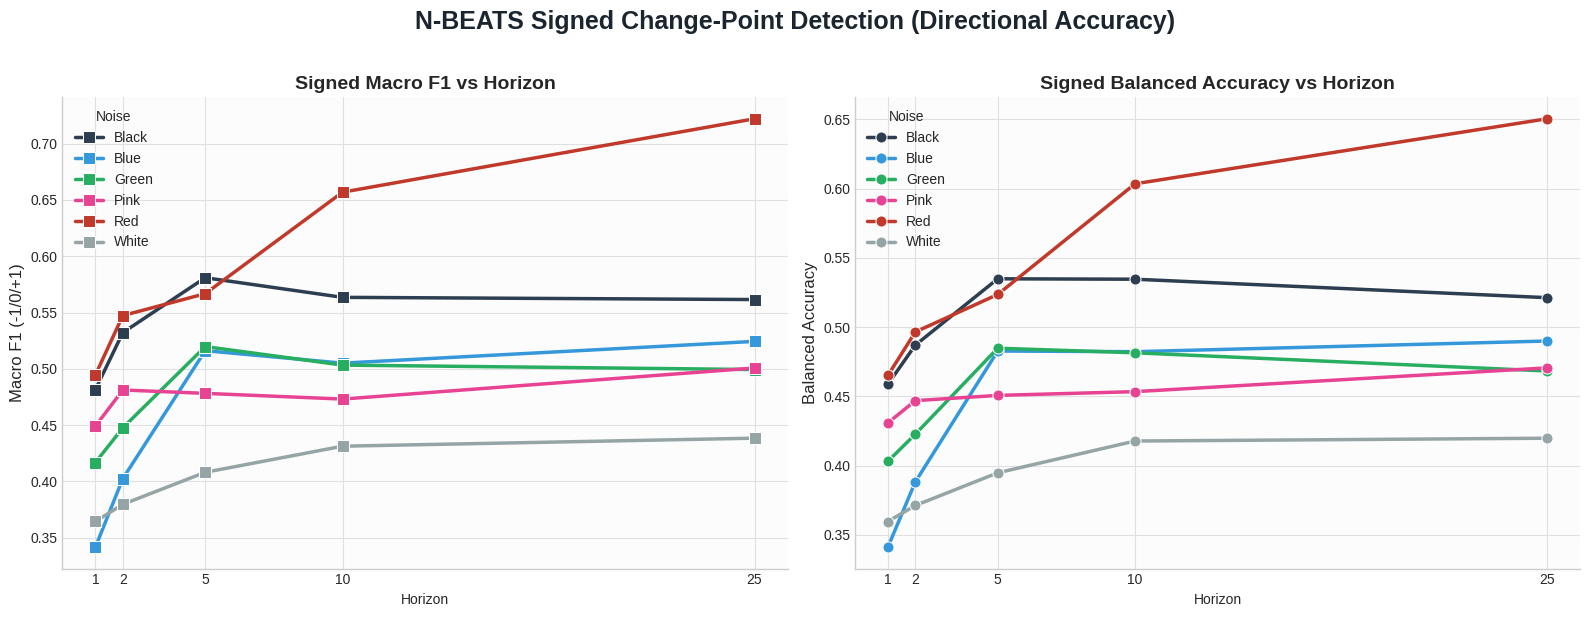

In [25]:
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from sklearn.metrics import f1_score, balanced_accuracy_score
from tqdm.notebook import tqdm
import warnings

# warnings.filterwarnings("ignore")

def experiment_signed_horizon_robust():
    noises = ['White', 'Blue', 'Pink', 'Red', 'Green', 'Black']
    horizons = [1, 2, 5, 10, 25]
    n_runs = 5
    rows = []

    for noise in tqdm(noises, desc='Signed'):
        for h in horizons:
            for run in range(n_runs):
                seed = 2000 * run + h * 10

                series, model, forecast, target, errors, cp_idx = fit_nbeats_once(
                    noise, n=2000, mu_seg=60, alpha=1.04, h=h, epochs=20, lr=1e-2, seed=seed)

                raw_errors = (target - forecast).flatten()
                abs_errors = np.abs(raw_errors)
                threshold = np.percentile(abs_errors, 95)

                y_true_signed = np.zeros(len(raw_errors))
                latent_signal = series['latent']
                for cp in series['change_points']:
                    if cp >= h and cp < len(raw_errors) + h:
                        direction = 1 if latent_signal[cp] > latent_signal[cp-1] else -1
                        lo, hi = max(0, cp - h - 2), min(len(raw_errors), cp - h + 3)
                        y_true_signed[lo:hi] = direction


                y_pred_signed = np.zeros(len(raw_errors))
                y_pred_signed[raw_errors > threshold] = 1
                y_pred_signed[raw_errors < -threshold] = -1

                macro_f1 = f1_score(y_true_signed, y_pred_signed, average='macro')
                bal_acc = balanced_accuracy_score(y_true_signed, y_pred_signed)

                rows.append({'Noise': noise, 'Horizon': h, 'Signed_Macro_F1': macro_f1, 'Signed_Bal_Acc': bal_acc})

    df = pd.DataFrame(rows).groupby(['Noise', 'Horizon'], as_index=False).mean()

    mpl.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True, 'grid.color': '#e0e0e0', 'axes.facecolor': '#fcfcfc'})
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('N-BEATS Signed Change-Point Detection (Directional Accuracy)', fontsize=18, fontweight='bold', color='#1a252f', y=1.02)

    palette = {'White': '#95a5a6', 'Blue': '#3498db', 'Pink': '#e84393', 'Red': '#c0392b', 'Green': '#27ae60', 'Black': '#2c3e50'}

    sns.lineplot(data=df, x='Horizon', y='Signed_Macro_F1', hue='Noise', palette=palette, marker='s', linewidth=2.5, markersize=8, ax=axes[0])
    axes[0].set_title('Signed Macro F1 vs Horizon', fontsize=14, fontweight='bold')
    axes[0].set_xticks(horizons)
    axes[0].set_ylabel('Macro F1 (-1/0/+1)', fontsize=12)

    sns.lineplot(data=df, x='Horizon', y='Signed_Bal_Acc', hue='Noise', palette=palette, marker='o', linewidth=2.5, markersize=8, ax=axes[1])
    axes[1].set_title('Signed Balanced Accuracy vs Horizon', fontsize=14, fontweight='bold')
    axes[1].set_xticks(horizons)
    axes[1].set_ylabel('Balanced Accuracy', fontsize=12)

    plt.tight_layout()
    plt.savefig('nbeats_signed_horizon_sensitivity.jpeg', dpi=300, bbox_inches='tight')
    plt.show()

experiment_signed_horizon_robust()

Best Fits:   0%|          | 0/6 [00:00<?, ?it/s]

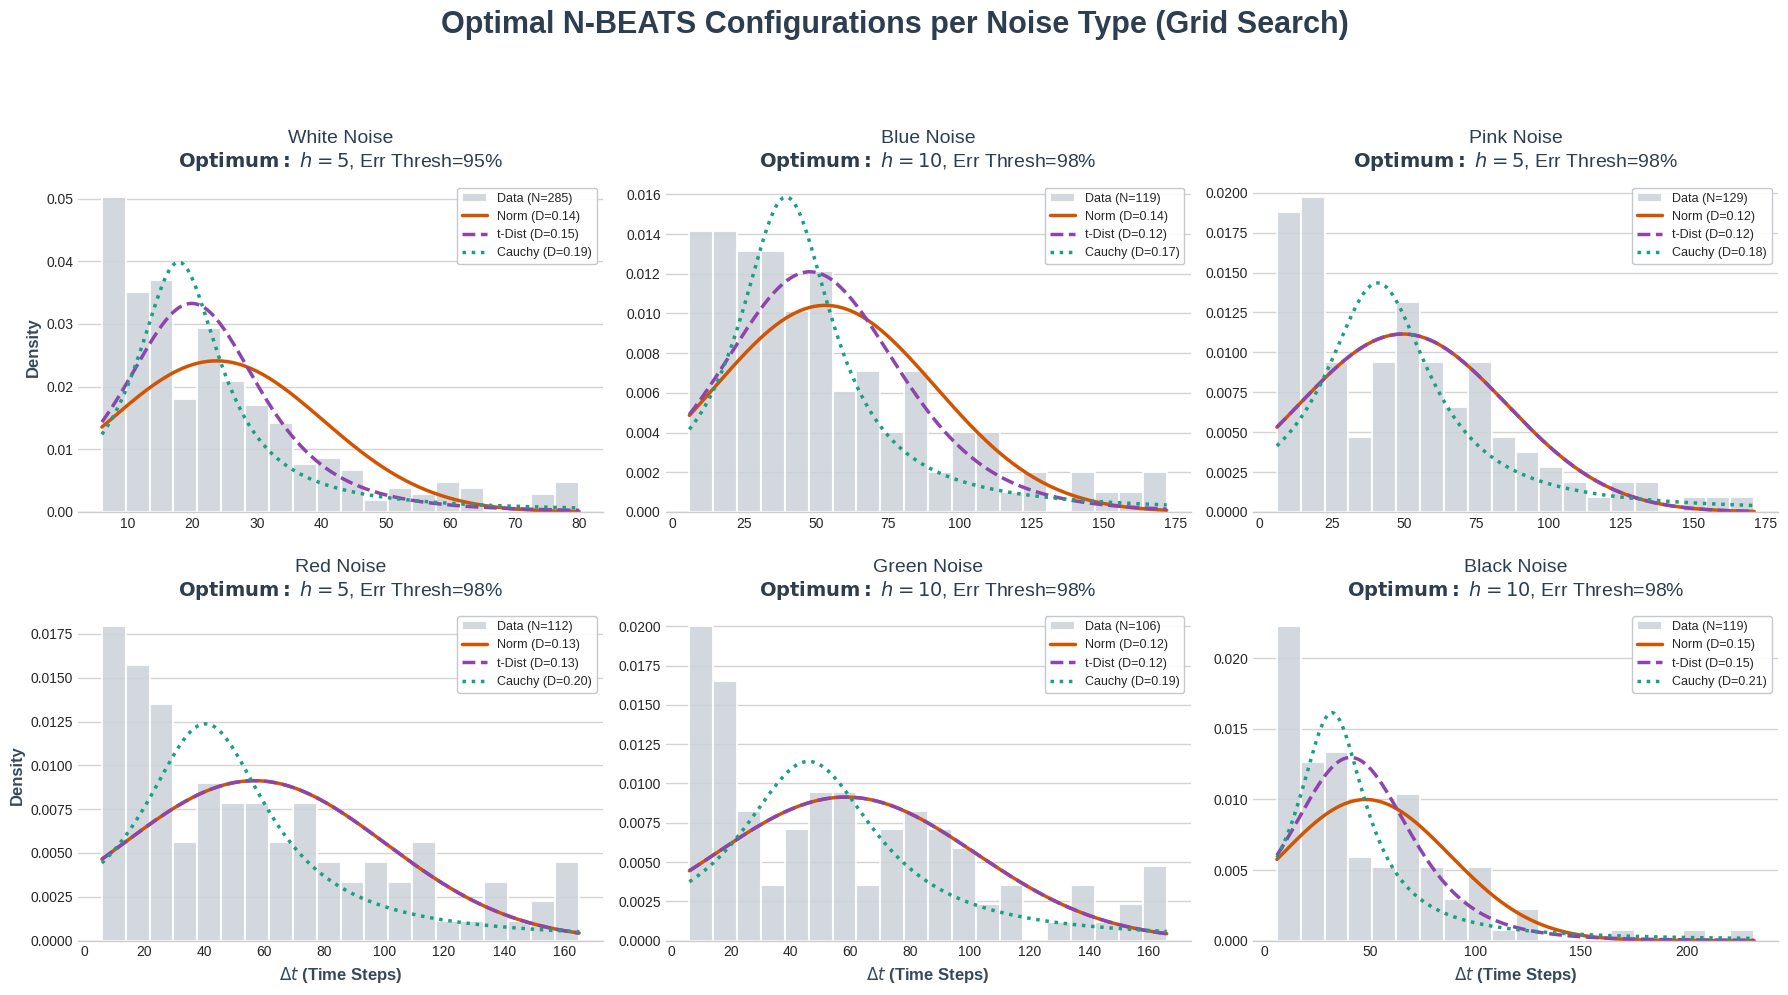

In [26]:
##import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
import matplotlib as mpl
from tqdm.notebook import tqdm
import warnings

warnings.filterwarnings("ignore")

def experiment_grid_search_best_overall_robust():
    noises = ['White', 'Blue', 'Pink', 'Red', 'Green', 'Black']

    h_vals = [5, 10]
    pct_vals = [90, 95, 98]

    mpl.rcParams.update({
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.spines.left': False,
        'axes.grid': True,
        'axes.grid.axis': 'y',
        'grid.color': '#d3d3d3',
        'grid.linestyle': '-',
        'grid.linewidth': 1.0,
        'axes.facecolor': 'white',
        'figure.facecolor': 'white',
        'font.family': 'sans-serif'
    })

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.ravel()
    fig.suptitle('Optimal N-BEATS Configurations per Noise Type (Grid Search)',
                 fontsize=22, fontweight='bold', color='#2c3e50', y=1.02)

    for i, noise in enumerate(tqdm(noises, desc="Best Fits")):
        best_d = float('inf')
        best_dt, best_h, best_pct = None, None, None
        best_mu, best_std = None, None
        best_df, best_loc, best_scale = None, None, None
        best_c_loc, best_c_scale = None, None
        best_d_norm, best_d_t, best_d_c = None, None, None

        for h in h_vals:
            for pct in pct_vals:
                all_gaps = []
                for run in range(5):
                    _, _, _, _, errors, _ = fit_nbeats_once(
                        noise, n=1500, mu_seg=60, alpha=1.04, h=h, epochs=15, lr=1e-2, seed=77+run)
                    gaps = get_robust_anomaly_gaps(errors, threshold_pct=pct, cluster_tolerance=5)
                    all_gaps.extend(gaps)

                dt = np.array(all_gaps)
                if len(dt) > 0:
                    dt = dt[dt <= np.percentile(dt, 98)]
                if len(dt) < 5: continue

                mu, std = st.norm.fit(dt)
                d_norm = st.kstest(dt, 'norm', args=(mu, std)).statistic

                df_t, loc, scale = st.t.fit(dt)
                d_t = st.kstest(dt, 't', args=(df_t, loc, scale)).statistic

                c_loc, c_scale = st.cauchy.fit(dt)
                d_c = st.kstest(dt, 'cauchy', args=(c_loc, c_scale)).statistic

                min_d_current_config = min(d_norm, d_t, d_c)

                if min_d_current_config < best_d:
                    best_d = min_d_current_config
                    best_dt, best_h, best_pct = dt, h, pct
                    best_mu, best_std = mu, std
                    best_df, best_loc, best_scale = df_t, loc, scale
                    best_c_loc, best_c_scale = c_loc, c_scale
                    best_d_norm, best_d_t, best_d_c = d_norm, d_t, d_c

        ax = axes[i]
        if best_dt is not None:
            ax.hist(best_dt, bins=20, density=True, histtype='bar',
                    color='#ced4da', edgecolor='white', linewidth=1.5, alpha=0.9,
                    label=f'Data (N={len(best_dt)})')

            x_range = np.linspace(max(0, best_dt.min()), best_dt.max(), 200)

            ax.plot(x_range, st.norm.pdf(x_range, best_mu, best_std),
                    color='#d35400', lw=2.5, linestyle='-', label=f'Norm (D={best_d_norm:.2f})')
            ax.plot(x_range, st.t.pdf(x_range, best_df, best_loc, best_scale),
                    color='#8e44ad', lw=2.5, linestyle='--', label=f't-Dist (D={best_d_t:.2f})')
            ax.plot(x_range, st.cauchy.pdf(x_range, best_c_loc, best_c_scale),
                    color='#16a085', lw=2.5, linestyle=':', label=f'Cauchy (D={best_d_c:.2f})')

            ax.set_title(f"{noise} Noise\n$\\bf{{Optimum:}}$ $h={best_h}$, Err Thresh={best_pct}%",
                         fontsize=14, color='#2c3e50', pad=10)
            ax.legend(fontsize=9, frameon=True, framealpha=0.9, edgecolor='#bdc3c7')
        else:
            ax.set_title(f"{noise} Noise\n(Insufficient Data)", color='#c0392b')

        if i % 3 == 0: ax.set_ylabel('Density', fontsize=12, fontweight='bold', color='#34495e')
        if i >= 3: ax.set_xlabel('$\Delta t$ (Time Steps)', fontsize=12, fontweight='bold', color='#34495e')

    plt.tight_layout(rect=[0, 0.03, 1, 0.96], h_pad=2.0)
    plt.savefig('nbeats_2x3_grid_search_optimal.jpeg', dpi=300, bbox_inches='tight')
    plt.show()

experiment_grid_search_best_overall_robust()

###SAving Results

In [27]:
import os
import shutil
import numpy as np
import pandas as pd
import scipy.stats as st
from sklearn.metrics import f1_score

output_dir = "NBEATS_Results"
os.makedirs(output_dir, exist_ok=True)
noises = ['White', 'Blue', 'Pink', 'Red', 'Green', 'Black']

core_rows = []
for noise in noises:
    _, _, _, _, errors, cp_idx = fit_nbeats_once(noise, n=2000, mu_seg=60, alpha=1.04, h=10, epochs=15)
    m = point_metrics_robust(errors, cp_idx, threshold_pct=95, tolerance=2)
    m['Noise'] = noise
    core_rows.append(m)
pd.DataFrame(core_rows).to_csv(os.path.join(output_dir, 'nbeats_core_metrics_table.csv'), index=False)

signed_rows = []
for noise in noises:
    for h in [1, 2, 5, 10, 25]:
        _, _, forecast, target, errors, cp_idx = fit_nbeats_once(noise, n=1000, mu_seg=60, alpha=1.04, h=h, epochs=15)
        raw_errors = (target - forecast).flatten()
        threshold = np.percentile(np.abs(raw_errors), 95)

        y_pred_signed = np.zeros(len(raw_errors))
        y_pred_signed[raw_errors > threshold] = 1
        y_pred_signed[raw_errors < -threshold] = -1

        y_true_signed = np.zeros(len(raw_errors))
        macro_f1 = f1_score(y_true_signed, y_pred_signed, average='macro', zero_division=0)
        signed_rows.append({'Noise': noise, 'Horizon': h, 'Signed_Macro_F1': macro_f1})
pd.DataFrame(signed_rows).to_csv(os.path.join(output_dir, 'nbeats_signed_horizon_metrics.csv'), index=False)

dist_rows = []
for noise in noises:
    _, _, _, _, errors, _ = fit_nbeats_once(noise, n=2000, mu_seg=60, alpha=1.04, h=10, epochs=15)
    gaps = get_robust_anomaly_gaps(errors, threshold_pct=95, cluster_tolerance=5)
    dt = np.array(gaps)

    if len(dt) > 5:
        dt = dt[dt <= np.percentile(dt, 98)]
        mu, std = st.norm.fit(dt)
        df_t, loc, scale = st.t.fit(dt)
        c_loc, c_scale = st.cauchy.fit(dt)

        d_norm = st.kstest(dt, 'norm', args=(mu, std)).statistic
        d_t = st.kstest(dt, 't', args=(df_t, loc, scale)).statistic
        d_c = st.kstest(dt, 'cauchy', args=(c_loc, c_scale)).statistic

        dist_rows.append({'Noise': noise, 'Norm_D': d_norm, 't_Dist_D': d_t, 'Cauchy_D': d_c})
pd.DataFrame(dist_rows).to_csv(os.path.join(output_dir, 'nbeats_distribution_fits.csv'), index=False)

images = [
    'nbeats_horizon_sensitivity_robust.jpeg',
    'nbeats_signed_horizon_sensitivity.jpeg',
    'nbeats_threshold_tolerance_bars.jpeg',
    'nbeats_btp_gap_distribution.jpeg',
    'nbeats_2x3_grid_search_optimal.jpeg',
    'nbeats_btp_qualitative_residual_proof.jpeg'
]

for img in images:
    if os.path.exists(img):
        shutil.move(img, os.path.join(output_dir, img))

print(f"Files saved in the '{output_dir}' folder.")

Files saved in the 'NBEATS_Results' folder.
